# S. Appendix

### S.1 Additional Experimental Setups

In this study, the model design and training process followed the research procedures described in previous studies [1,2]. To ensure fair comparisons among all experiments, a consistent network architecture and training configuration were maintained across all methods. Unless otherwise specified, the Physics-Informed Deep Operator Network model comprises a Trunk Network, a Branch Network, and a Gating Network, each containing five hidden layers with 256 neurons per layer and employing the GELU activation function. The network parameters were initialized using the default scheme in PyTorch.

The loss function follows the PIDoN formulation, in which weights are assigned to the data-fitting, ODE residual, and initial condition terms. The experimental validation was performed by measuring the volumetric flowrate.

$$
\hat{q}(t) \approx G_\theta [v](t) \approx \psi(v,t;\theta^*)
\tag{S.1}
$$

$$
L_{\mathrm{Data}} = \frac{1}{N_t} \sum_{i=1}^{N_t} \left[\hat{q}(t_i)-q(t_i)\right]^2,
$$

$$
L_{\mathrm{Res}} = \frac{1}{N_t} \sum_{i=1}^{N_t} \left[\left\{L\ddot{q}(t_i)+R\dot{q}(t_i)+\frac{1}{C}q(t_i)\right\}-F U_A(t_i)\right]^2,
$$

$$
L_{\mathrm{Init}} = \left[q(t_0)-0\right]^2 + \left[L\dot{q}(t_0)-0\right]^2
\tag{S.2}
$$

The total loss is defined as:

$$
L_{\mathrm{Tot}} = \lambda_{\mathrm{Data}} L_{\mathrm{Data}} + \lambda_{\mathrm{Res}} L_{\mathrm{Res}} + \lambda_{\mathrm{Init}} L_{\mathrm{Init}}
\tag{S.3}
$$

where $L_{\mathrm{Data}}$, $L_{\mathrm{Res}}$, and $L_{\mathrm{Init}}$ denote the mean squared errors associated with the supervised data, ODE residual, and initial condition, respectively. In the present implementation, the weighting factors were set to $\lambda_{\mathrm{Data}} = 10^{5}$, $\lambda_{\mathrm{Res}} = 10^{-9}$, and $\lambda_{\mathrm{Init}} = 10^{2}$. The model was optimized using the Adam optimizer in conjunction with a cosine-annealing learning-rate scheduler. The data sampling followed a mesh-free PIDoN framework, where collocation points were distributed over the entire temporal domain. For the time-dependent problem, the measured waveform consisted of 300 uniformly spaced samples over a total physical duration of 300 $\mu$s. The supervised data points for the data-fitting term were sampled over the full normalized time domain, while the ODE residual was evaluated at 200 temporal collocation points over the same interval. To enforce the initial condition, a collocation point was imposed at $t_0 = 0$.

In this section, we provide a detailed description of the Deep Operator Network (DoN) architecture, a systematic methodology for domain-specific feature extraction, parameter initialization, normalization techniques, and the overall operational workflow. The integrated PIDoN model is designed to solve the ODE by incorporating learnable feature mappings and domain-specific knowledge into the neural network framework.

The DoN employed in this study consists of three primary components: the Branch Network, the Trunk Network, and an auxiliary Gating Network. The architecture is summarized as follows:

- **Branch Network:** 6 hidden layers, each with 256 neurons and GELU activation, mapping the four input parameters to a latent representation.
- **Trunk Network:** 6 hidden layers, each with 256 neurons and GELU activation, mapping the temporal input to a latent representation.
- **Gating Network:** 6 hidden layers, each with 256 neurons and GELU activation, followed by a sigmoid activation to provide gating modulation over the latent space.
- **Latent Dimension:** Each network outputs a latent vector of dimension 32.
- **Output Layer:** The final operator output is obtained by the element-wise product of the Branch, Trunk, and Gating Network outputs, followed by summation over the latent dimension and the addition of a learnable bias term.

---

### S.2 Physics-Informed Deep Operator Network modeling

The Deep Operator Network (DoN) is an artificial neural network architecture for operator learning, which aims to map an entire input function to a target function (Lu et al., 2021). In this framework, the operator is approximated via inner-product fusion between the Branch Network (processing sampled input-function values) and the Trunk Network (processing output-domain coordinates) (Li et al., 2020). By the universal approximation theorem for operators, DoN can approximate nonlinear operators to arbitrary accuracy, enabling modeling of complex physical systems and inverse problems (Chen and Chen, 1995; Lu et al., 2021).

To achieve this, an input function $v$ in an infinite-dimensional space is discretized into $N$ samples, yielding a finite-dimensional vector:
$$
\mathbf{v} = [v(t_1),\, v(t_2),\, v(t_3),\, \ldots,\, v(t_N)]^{\top} \in \mathbb{R}^{N}.
\tag{S.4}
$$

The input vector $\mathbf{v}$ is passed through a feed-forward neural network (the Branch Network) to generate a latent representation parameterized by $\theta_B$:
$$
B(\mathbf{v}) = \mathcal{N}_{\mathrm{Branch}}(\mathbf{v}; \theta_B) \in \mathbb{R}^{l}.
\tag{S.5}
$$

The Branch Network updates each hidden layer during training according to:
$$
\mathbf{h}^{(k+1)} = z\!\left(W^{(k)} \mathbf{h}^{(k)} + \mathbf{b}^{(k)}\right),
\qquad k = 0,1,\ldots,n-1,
\tag{S.6}
$$
where $z(\cdot)$ denotes the activation function and $\mathbf{b}^{(k)}$ is the bias vector.

The Trunk Network takes the output-domain coordinates $t$ as input and generates the latent vector at each location:
$$
T(t) = \mathcal{N}_{\mathrm{Trunk}}(t; \theta_T) \in \mathbb{R}^{l}.
\tag{S.7}
$$

Each hidden layer of the Trunk Network is updated as:
$$
\mathbf{h}^{(s+1)} = z\!\left(W^{(s)} \mathbf{h}^{(s)} + \mathbf{b}^{(s)}\right),
\qquad s = 0,1,\ldots,n-1.
\tag{S.8}
$$

The set of trainable parameters in both networks is:
$$
\theta =
\left\{
\{W_B^{(k)}\},\, \{\mathbf{b}_B^{(k)}\},\, \{W_T^{(s)}\},\, \{\mathbf{b}_T^{(s)}\}
\right\}_{(l,s)}.
\tag{S.9}
$$

The predictive function generated by the operator is given by the inner product of Branch and Trunk features:
$$
\psi(\mathbf{v}, t; \theta)
=
\langle B(\mathbf{v}), T(t) \rangle + b_0
=
\sum_{j=1}^{l} B_j(\mathbf{v})\, T_j(t) + b_0,
\tag{S.10}
$$
where $b_0$ is the bias term.

Consequently, the operator of the Deep Operator Network is represented as:
$$
G[v](t) \approx \psi(\mathbf{v}, t; \theta^{*}),
\tag{S.11}
$$
where $\theta^{*}$ denotes the optimized network parameters.

The predicted output $q(t)$ is governed by the ODE:
$$
\dot{q}(t) + \mathcal{N}[q(t), t] = 0,
\qquad t \in (0, t_{\mathrm{fin}}].
\tag{S.12}
$$

Upon receiving the input function $v$, the network returns the solution $q(t,\cdot)$ over the temporal domain. The objective of the Physics-Informed Deep Operator Network (PIDoN) is to approximate and learn this operator using the neural representation $\psi(\mathbf{v}, t; \theta^{*})$.

The total cost formulation is expressed as:
$$
\nabla_{\theta} L_{\mathrm{Tot}}
=
\sum_{s} \delta_{s}\, \nabla_{\theta}\, \psi(\mathbf{v}, t; \theta),
\tag{S.13}
$$
where $\delta_s$ denotes the weighted contribution of each loss component.

Finally, the objective is to determine the optimal parameter set that minimizes the total loss:
$$
\theta^{*} = \arg\min_{\theta}\, L_{\mathrm{Tot}}(\theta).
\tag{S.14}
$$

---


### S.3 Parameter identification modeling

In the present work, parameter identification is formulated as a linear inverse problem driven by the PIDoN outputs (Lu, 2021; Chen, 1995). Given the PIDoN prediction $\hat{q}(t)$ and its time derivatives, a regressor is constructed to map unknown physical parameters to the measured driving voltage $\mathrm{d}U_A/\mathrm{d}t$. Let $m$ be the number of observation instants and $k$ the number of unknown parameters (Kovachki, 2021). Define the regressor matrix $\Phi \in \mathbb{R}^{m \times k}$, the parameter vector $W_{\mathrm{PI}} \in \mathbb{R}^{k}$, and the target vector $\mathbf{f} \in \mathbb{R}^{m}$ (Li, 2020). The baseline identification is written as:
$$
\Phi W_{\mathrm{PI}} = \mathbf{f}.
\tag{S.15}
$$

In the PIDoN framework, the regressor is generated from the neural-operator outputs as:
$$
\hat{\mathbf{q}}(t) =
\begin{bmatrix}
q(t)\\
\dot{q}(t)\\
\ddot{q}(t)
\end{bmatrix},
\qquad
\mathbf{P} =
\begin{bmatrix}
R\\
L\\
C\\
F
\end{bmatrix}
\in \mathbb{R}^{k}.
\tag{S.16}
$$

The operator-induced regressor and the measured actuation vector are defined by:
$$
G(\hat{\mathbf{q}};\theta) \in \mathbb{R}^{m \times k},
\qquad
\mathbf{U}_A =
\begin{bmatrix}
U_A(t_1)\\
\vdots\\
U_A(t_m)
\end{bmatrix}
\in \mathbb{R}^{m}.
\tag{S.17}
$$

Then, the parameter identification model can be written as:
$$
G(\hat{\mathbf{q}};\theta)\,\mathbf{P} = \mathbf{U}_A.
\tag{S.18}
$$

To estimate the unknown parameters, the least-squares principle is adopted:
$$
\min_{W_{\mathrm{PI}} \in \mathbb{R}^{k}}
\left\lVert \Phi W_{\mathrm{PI}} - \mathbf{f} \right\rVert_2^2.
\tag{S.19}
$$

The analytical solution is obtained from the normal equation:
$$
W_{\mathrm{PI}}^{*} = (\Phi^{\top}\Phi)^{-1}\Phi^{\top}\mathbf{f}.
\tag{S.20}
$$

For a gradient-based update, define the least-squares cost:
$$
J(W_{\mathrm{PI}}) = \frac{1}{2}\left\lVert \Phi W_{\mathrm{PI}} - \mathbf{f} \right\rVert_2^2.
\tag{S.21}
$$

Taking the gradient with respect to $W_{\mathrm{PI}}$ yields:
$$
\nabla_{W_{\mathrm{PI}}} J(W_{\mathrm{PI}})
=
\Phi^{\top}(\Phi W_{\mathrm{PI}} - \mathbf{f}).
\tag{S.22}
$$

To incorporate physical constraints, the residual of the governing equation is introduced as the PIDoN physics loss. At each time instant $t$, the residual is expressed as:
$$
r_{\theta}(t;\mathbf{P})
=
L\,\ddot{q}_{\theta}(t)
+
R\,\dot{q}_{\theta}(t)
+
\frac{1}{C}q_{\theta}(t)
-
F\,\dot{U}_A(t).
\tag{S.23}
$$

The physics residual loss is computed as the mean-squared residual over $N_t$ temporal collocation points:
$$
L_{\mathrm{Res}}(\theta,\mathbf{P})
=
\frac{1}{N_t}\sum_{i=1}^{N_t}\left[r_{\theta}(t_i;\mathbf{P})\right]^2.
\tag{S.24}
$$

The parameter updates are performed through backpropagation of the total loss:
$$
\nabla_{\theta} L_{\mathrm{Tot}}
=
\sum_{s}\delta_s\,\nabla_{\theta}\,\psi(\mathbf{v},t;\theta).
\tag{S.25}
$$

The trainable parameter set includes both neural network weights and the physical coefficients:
$$
\theta =
\left[W^{(l)},\, b^{(l)},\, W^{(s)},\, b^{(s)},\, R,\, L,\, C,\, F \right]_{(l,s)}.
\tag{S.26}
$$

The gradients of each loss term with respect to $\theta$ are:
$$
\nabla_{\theta} L_{\mathrm{Data}}
=
\frac{2\lambda_{\mathrm{Data}}}{N_t}\sum_{i=1}^{N_t}
\left[
\frac{\partial q_{\theta}(t_i)}{\partial \theta}\,
\left(q_{\theta}(t_i)-\hat{q}(t_i)\right)
\right],
$$

$$
\nabla_{\theta} L_{\mathrm{Res}}
=
\frac{2\lambda_{\mathrm{Res}}}{N_t}\sum_{i=1}^{N_t}
\left[
\frac{\partial r_{\theta}(t_i;\mathbf{P})}{\partial \theta}\,
r_{\theta}(t_i;\mathbf{P})
\right],
$$

$$
\nabla_{\theta} L_{\mathrm{Init}}
=
2\lambda_{\mathrm{Init}}
\left[
\frac{\partial q_{\theta}(t_0)}{\partial \theta}\,
\left(q_{\theta}(t_0)-0\right)
\right]
+
2\lambda_{\mathrm{Init}}
\left[
\frac{\partial \dot{q}_{\theta}(t_0)}{\partial \theta}\,
\left(L\dot{q}_{\theta}(t_0)-0\right)
\right].
\tag{S.27}
$$

The total composite loss function is:
$$
L_{\mathrm{Tot}}(\theta,\mathbf{P})
=
\lambda_{\mathrm{Data}}L_{\mathrm{Data}}
+
\lambda_{\mathrm{Res}}L_{\mathrm{Res}}
+
\lambda_{\mathrm{Init}}L_{\mathrm{Init}}.
\tag{S.28}
$$

At each iteration, the physical coefficients are updated in the direction that minimizes the total loss:
$$
(\hat{R},\hat{L},\hat{C},\hat{F})
\leftarrow
(R^{*},L^{*},C^{*},F^{*})
-
\eta\,\frac{\partial L_{\mathrm{Tot}}}{\partial \theta}.
\tag{S.29}
$$
where $\eta$ denotes the learning rate.

The final optimal set of parameters is obtained by minimizing the total loss with respect to both the neural parameters $\theta$ and the physical parameters $\mathbf{P}$:
$$
(\theta^{*}, \mathbf{P}^{*})
=
\arg\min_{\theta,\mathbf{P}}
L_{\mathrm{Tot}}(\theta,\mathbf{P}).
\tag{S.30}
$$

Through this framework, the present study proposes an operating-condition analysis method based on inversely identified material properties under varying ink-property and voltage conditions. Because this approach reflects the physical relationship between actuator driving conditions, material properties, and the interfacial volumetric flowrate response, it can be used as an effective criterion for real-time monitoring and interpretation of droplet formation behavior. Furthermore, the transient interfacial response was transformed into representative dynamic-response parameters, enabling a more systematic analysis of time-dependent droplet behavior. Therefore, the proposed inverse Physics-Informed DeepONet framework provides a practical basis for analyzing operating conditions and evaluating droplet formation stability in piezoelectric inkjet systems.

---
---

# Data acquisition

In this study, the experimentally measured interfacial displacement was obtained to secure the data acquisition. To ensure the reliability of the physical trends, physical validation was performed under the same conditions as those used in the experiments. The configuration of the experimental measurement system is presented below.

<div align="center">
  <img src="Fig 1..jpg" alt="Experiment setup" width="1000"><br>
  Fig. 1. Experimental setup: (a) actual experimental system and (b) schematic diagram of the experimental procedure.
</div>

- The developed Inverse Physics-Informed Deep Operator Network model predicts the volumetric flow rate and estimates real-time material property conditions based on the ink properties, voltage waveform, and operating conditions.

- For this purpose, six types of ethylene glycol (EG) were used in the experiments to define the ink property conditions.

- The volumetric flow rate was determined by measuring the flow displacement at the nozzle interface under driving voltages ranging from 20 to 40 V.

- This approach enabled the establishment of precise operating conditions by validating the physical trends observed in the actual experiments.

<div align="center">
  <b>Table 1.</b> Physical property conditions of the piezoelectric inkjet
</div>

<div align="center">

| EG     | Surface tension, $\sigma$ [N/m] | Dynamic viscosity, $\mu$ [Pa·s] | Density, $\rho$ [kg/m³] | Piezoelectric coefficient, $\alpha$ [m/V] | Speed of sound, $c$ [m/s] |
| ------ | ------------------------------: | ------------------------------: | ----------------------: | ----------------------------------------: | ------------------------: |
| EG 100 |                          0.0474 |                          0.0157 |                 1114.00 |                                  2.90e-10 |                   1688.00 |
| EG 90  |                          0.0497 |                          0.0105 |                 1101.00 |                                  2.90e-10 |                   1688.00 |
| EG 75  |                          0.0521 |                          0.0064 |                 1081.00 |                                  2.90e-10 |                   1709.38 |
| EG 65  |                          0.0539 |                          0.0049 |                 1070.00 |                                  2.90e-10 |                   1707.98 |
| EG 60  |                          0.0551 |                          0.0041 |                 1072.00 |                                  2.90e-10 |                   1703.27 |
| EG 50  |                          0.0565 |                          0.0030 |                 1056.00 |                                  2.90e-10 |                   1638.21 |

</div>

<div align="center">
  <img src="Fig 2..jpg" alt="Voltage waveform condition" width="1200"><br>
  Fig 2. Voltage waveform condition
</div>

---
---

# Hyperparameter tunning

In the present model, hyperparameter tuning was performed by varying the number of training data points, the number of collocation points, the learning rate, and the learning scheduler settings. In this study, the optimization procedure was initiated from the baseline hyperparameter conditions and subsequently refined through systematic validation. As a result, the best performance was obtained at 500 training points, 200 collocation points, and a learning rate of $1 \times 10^{-3}$. For the learning scheduler, the most favorable performance was observed within the range of $1 \times 10^{-4}$ to $1 \times 10^{-3}$. These findings indicate that variations in the tested hyperparameters had a substantial influence on the overall training error, suggesting that they constitute critical factors for achieving stable convergence of the model.

Accordingly, the final training conditions may be selected by jointly considering computational efficiency and implementation stability. However, under extended conditions, a reduction in reproducibility was observed.

<div align="center">
  <b>Table 2.</b> Validation of the total loss according to the number of training points.
</div>

<div align="center">

| Condition  | 200 | 300 | 400 | 500 | 600 |
|:----------:|:---:|:---:|:---:|:---:|:---:|
| Total loss | $1.72 \times 10^{6}$ | $5.25 \times 10^{6}$ | $4.25 \times 10^{5}$ | $2.25 \times 10^{5}$ | $6.32 \times 10^{5}$ |

</div>

<br>

<div align="center">
  <b>Table 3.</b> Validation of the total loss according to the number of collocation points.
</div>

<div align="center">

| Condition  | 200   | 300   | 400   | 500   | 600   |
|:----------:|:-----:|:-----:|:-----:|:-----:|:-----:|
| Total loss | $1.54 \times 10^{5}$ | $3.79 \times 10^{5}$ | $5.20 \times 10^{5}$ | $1.32 \times 10^{6}$ | $3.20 \times 10^{6}$ |

</div>

<br>

<div align="center">
  <b>Table 4.</b> Validation of the total loss according to the learning rate.
</div>

<div align="center">

| Condition  | $5 \times 10^{-3}$ | $1 \times 10^{-3}$ | $5 \times 10^{-4}$ | $1 \times 10^{-4}$ | $5 \times 10^{-5}$ |
|:----------:|:------------------:|:------------------:|:------------------:|:------------------:|:------------------:|
| Total loss | $2.32 \times 10^{5}$ | $1.20 \times 10^{5}$ | $1.25 \times 10^{5}$ | $4.25 \times 10^{5}$ | $5.25 \times 10^{6}$ |

</div>

<br>

<div align="center">
  <b>Table 5.</b> Validation of the total loss according to the scheduler setting.
</div>

<div align="center">

| Condition  | $5 \times 10^{-3}$ | $1 \times 10^{-3}$ | $5 \times 10^{-4}$ | $1 \times 10^{-4}$ | $5 \times 10^{-5}$ |
|:----------:|:------------------:|:------------------:|:------------------:|:------------------:|:------------------:|
| Total loss | $5.25 \times 10^{5}$ | $2.25 \times 10^{5}$ | $1.25 \times 10^{5}$ | $2.30 \times 10^{5}$ | $4.25 \times 10^{5}$ |

</div>

---
---

# Training & Prediction

### Result 1. Hyper-parameter Tunning Results: (a) Evolution of Gradient Norm and Data, Physics, and Initial Losses; (b) Evolution of Volumetric Flowrate and Derivative Term Magnitudes.

  2000 | Total loss 1.25e+05 | IC loss 1.22e-01 | Data loss 1.22e+00 | Res loss 2.85e+12
  4000 | Total loss 1.05e+05 | IC loss 2.41e-01 | Data loss 1.02e+00 | Res loss 3.48e+12
  6000 | Total loss 1.05e+05 | IC loss 2.48e-01 | Data loss 1.02e+00 | Res loss 3.49e+12


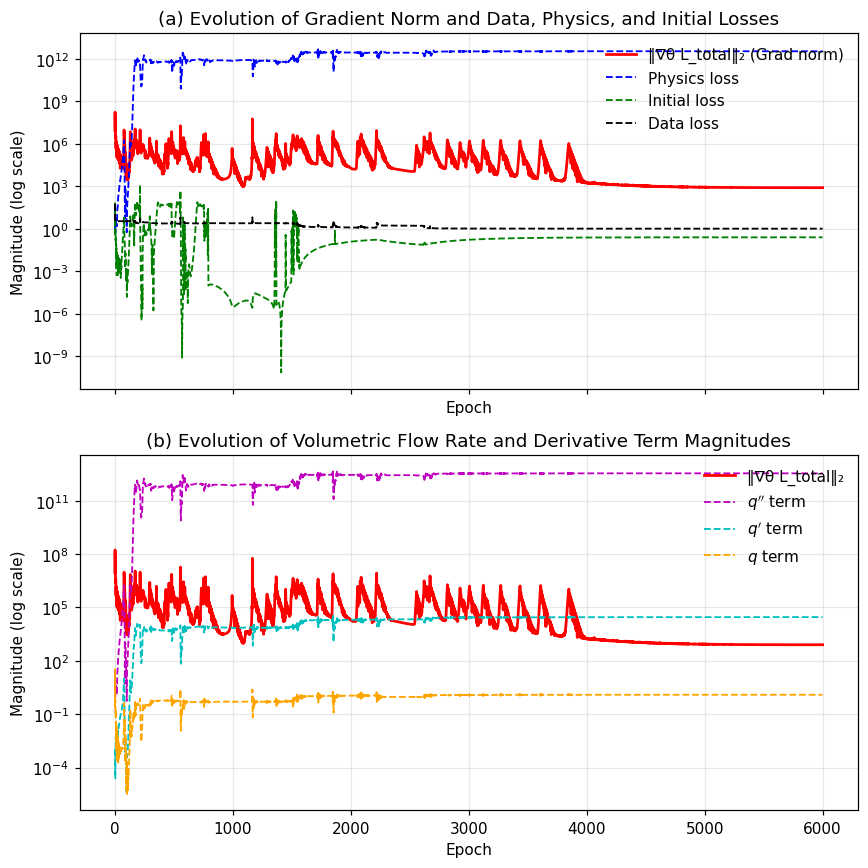

In [33]:
# ═════════════ 0. Library · environment ─══════════════════════════
import math, pandas as pd
from collections import OrderedDict
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os, sys, re

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float32)
plt.rcParams["figure.dpi"] = 110

# ═════════════ 1. External forcing term f_ext(t,F) ─═════════════════════════

"""
               [unit conversion]

# L*q_ddot + R*q_dot + (1/C)*q = F*dU_dt [Pa/s]

# L*q_ddot :  [Pa·s^2/m^3] * [m^3/s^3] = [Pa/s]
# R*q_dot  :  [Pa·s/m^3]   * [m^3/s^2] = [Pa/s]
# (1/C)*q  :  [Pa/m^3]     * [m^3/s]   = [Pa/s]
# F*dU_dt  :  [Pa/V]       * [V/s]     = [Pa/s]
"""

# R      : [Pa·s/m^3]      >      [Pa·us/um^3]
# L      : [Pa·s^2/m^3]    >      [Pa·us^2/um^3]
# C      : [m^3/Pa]        >      [um^3/Pa]
# F      : [Pa/V]          >      [Pa/V]

# q      : [m^3/s]         >      [um^3/us]
# q_dot  : [m^3/s^2]       >      [um^3/us^2]
# q_ddot : [m^3/s^3]       >      [um^3/us^3]

# dU_dt  : [V/s]           >      [V/us]

# Ω_time ⊂ [0, 3e-4] > Ω_time ⊂ [0, 1]
Norm_T = 3e-4
t1_phys, t2_phys, t3_phys, V_max = 6e-6, 26e-6, 32e-6, 24
t1 = t1_phys / Norm_T          # [-]
t2 = t2_phys / Norm_T          # [-]
t3 = t3_phys / Norm_T          # [-]

#   Time-axis remapping (value-preserving):
#   T = t / Norm_T,  t ∈ [0, Norm_T]  ⇔  T ∈ [0, 1]
#   f_val(T) := f_val_phys(t) with t = Norm_T·T  (i.e., f_val(T) = f_val_phys(Norm_T·T); numerical values are preserved under the reparameterization)

def f_ext(t, F_gain):  # f_ext [Pa/s]
    f_val = (
        V_max/t1 * (1 - (t > (t1)).float())
        - V_max/(t3 - t2) * ((t > (t2)).float() - (t > (t3)).float())
    )
    return F_gain * (f_val * Norm_T)   # F_gain = F [Pa/V], f_val = dU_dt [V/s] ; f_ext [Pa/s] = F_gain*f_val/Norm_T [Pa/V]*[V/s]/[us] ; recover the original f_ext value '(f_val*Norm_T)'


# ═════════════ 2. Experimental CSV → training·validation set ─══════════════════
"""
n_full : number of points in the full waveform (uniform grid over [0, t_end])
t_full : full time grid of size (n_full, 1)
y_full : full measured flowrate waveform sampled at t_full (shape: (n_full, 1))

n_data : number of supervised data points subsampled from the full waveform (within data_range)
x_data : selected time locations for data loss (t_full indexed by idx), shape: (n_data, 1)
y_data : selected measured values corresponding to x_data, shape: (n_data, 1)
"""
def load_experiment_csv(csv_path, t_end=1.0, n_full=300,
                        data_range=(0.0, 1.0), n_data=500):
    df     = pd.read_csv(csv_path)
    vals   = df.iloc[0, :n_full].astype(np.float32).to_numpy()
    y_full = torch.from_numpy(vals).view(-1, 1).to(DEVICE)
    t_full = torch.linspace(0.0, t_end, n_full, device=DEVICE).view(-1, 1)

    s, e = (int(data_range[0]/t_end*(n_full-1)),
            int(data_range[1]/t_end*(n_full-1)))
    idx  = torch.linspace(s, e, n_data, dtype=torch.long, device=DEVICE)
    return t_full, y_full, t_full[idx], y_full[idx]

csv_path = r"D:\Code review\Parameter identification\EG 90\3. EG90_24V.csv"
t_full, y_full, x_data, y_data = load_experiment_csv(csv_path)


# ═════════════ 3. PIDoN + g-Net ─═════════════════════════════
class PIDoN(nn.Module):
    def __init__(self, latent: int = 32):
        super().__init__()

        self.branch = nn.Sequential(OrderedDict([
            ("b1", nn.Linear(4,   256)), ("a1", nn.GELU()),
            ("b2", nn.Linear(256, 256)), ("a2", nn.GELU()),
            ("b3", nn.Linear(256, 256)), ("a3", nn.GELU()),
            ("b4", nn.Linear(256, 256)), ("a4", nn.GELU()),
            ("b5", nn.Linear(256, 256)), ("a5", nn.GELU()),
            ("b6", nn.Linear(256, 256)), ("a6", nn.GELU()),
            ("bout", nn.Linear(256, latent))
        ]))

        self.trunk = nn.Sequential(OrderedDict([
            ("t1", nn.Linear(1,   256)), ("a1", nn.GELU()),
            ("t2", nn.Linear(256, 256)), ("a2", nn.GELU()),
            ("t3", nn.Linear(256, 256)), ("a3", nn.GELU()),
            ("t4", nn.Linear(256, 256)), ("a4", nn.GELU()),
            ("t5", nn.Linear(256, 256)), ("a5", nn.GELU()),
            ("t6", nn.Linear(256, 256)), ("a6", nn.GELU()),
            ("tout", nn.Linear(256, latent))
        ]))

        self.g_net = nn.Sequential(OrderedDict([
            ("g1", nn.Linear(1,   256)), ("a1", nn.GELU()),
            ("g2", nn.Linear(256, 256)), ("a2", nn.GELU()),
            ("g3", nn.Linear(256, 256)), ("a3", nn.GELU()),
            ("g4", nn.Linear(256, 256)), ("a4", nn.GELU()),
            ("g5", nn.Linear(256, 256)), ("a5", nn.GELU()),
            ("g6", nn.Linear(256, 256)), ("a6", nn.GELU()),
            ("gout", nn.Linear(256, latent))
        ]))

        self.bias = nn.Parameter(torch.zeros(1, 1, dtype=torch.get_default_dtype()))

    def forward(self, t: torch.Tensor, params: torch.Tensor) -> torch.Tensor:
        B = self.branch(params)            # [B, latent]
        T = self.trunk(t)                  # [B, latent]
        G = torch.sigmoid(self.g_net(t))   # [B, latent]
        return torch.sum(B * T * G, dim=1, keepdim=True) + self.bias


model = PIDoN(latent=32).to(DEVICE)

# ═════════════ 4. Estimated parameters (bounded interval + oscillation damping) ─══════════════
R_MIN, R_MAX = 0.5, 3.0  # (0.5, 3.0)
L_MIN, L_MAX = 150, 350  # (150, 350)
C_MIN, C_MAX = 1.0, 1.75  # (1.0, 1.75)
F_MIN, F_MAX = 6900, 8000  # (6900, 8000)

# Trainable raw variables
L_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
R_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
C_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
F_raw = nn.Parameter(torch.zeros(1, device=DEVICE))


def bound_osc(raw, lo, hi, step: int,
              cur_lr: float, lr_init: float,
              amp0: float, cycles_total: float,
              phase: float = 0.0, amp_power: float = 2.0):
    """
    raw_osc = raw + amp(step) * sin(omega*step + phase)
    amp(step) = amp0 * (cur_lr/lr_init)^amp_power
    theta = sigmoid(raw_osc)  ->  param = lo + (hi-lo)*theta  in [lo, hi]
    """
    amp = amp0 * (max(cur_lr / lr_init, 0.0) ** amp_power)
    omega = 2.0 * math.pi * cycles_total / float(EPOCHS)

    sin_term = torch.sin(torch.tensor(omega * step + phase, device=DEVICE, dtype=raw.dtype))
    raw_osc = raw + amp * sin_term

    return lo + (hi - lo) * torch.sigmoid(raw_osc)

# ═════════════ 5. Loss weights & training setup ─═══════════════════
DATA_WEIGHT = 1e5
PHYS_WEIGHT = 1e-9 # 1e-9
IC_WEIGHT   = 1e2
LR_INIT = 1e-3

t_phys = torch.linspace(0, 1, 200, device=DEVICE).view(-1,1).requires_grad_(True)
t_ic   = torch.tensor([[0.0]], device=DEVICE, requires_grad=True)

# Each parameter has its own update weight
PARAM_UPDATE_WEIGHT = {"model": 1.0, "R": 1.0, "L": 1.0, "C": 1.0, "F": 1.0,}

optim = torch.optim.Adam([
    {"params": model.parameters(), "lr": LR_INIT * PARAM_UPDATE_WEIGHT["model"]},
    {"params": [R_raw],            "lr": LR_INIT * PARAM_UPDATE_WEIGHT["R"]},
    {"params": [L_raw],            "lr": LR_INIT * PARAM_UPDATE_WEIGHT["L"]},
    {"params": [C_raw],            "lr": LR_INIT * PARAM_UPDATE_WEIGHT["C"]},
    {"params": [F_raw],            "lr": LR_INIT * PARAM_UPDATE_WEIGHT["F"]},
])

EPOCHS       = 6_000
PRINT_EVERY  = 2_000
PLOT_EVERY   = 2_000

# Keep the ratio between parameter groups during scheduling
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=EPOCHS, eta_min=LR_INIT*5e-4)

# ═════════════ 5-1. Oscillation hyperparameters ───────────────────────
# amp0: initial oscillation amplitude in raw-space (too large -> unstable swings)
# cycles_total: total number of sine cycles over the entire training
# amp_power: decay rate of the oscillation as lr decreases (typ. 2–4)
# Initial setting: dict(amp0=0.80, cycles_total=25.0, phase=0.0, amp_power=2.5)
OSC_R = dict(amp0=0.95, cycles_total=10, phase=math.pi*2,  amp_power=50)
OSC_L = dict(amp0=0.95, cycles_total=10, phase=math.pi*2,  amp_power=50)
OSC_C = dict(amp0=0.95, cycles_total=10, phase=math.pi*2,  amp_power=50)
OSC_F = dict(amp0=0.95, cycles_total=10, phase=math.pi*2,  amp_power=50)

# ═════════════ 6. Parameter·LR history buffers ─═════════════════════
param_hist = {"epoch": [], "R": [], "L": [], "C": [], "F": []}
lr_hist    = {"epoch": [], "lr_model": [], "lr_R": [], "lr_L": [], "lr_C": [], "lr_F": []}

# 추가 history buffers
grad_hist = {"epoch": [], "grad_norm": []}
loss_hist = {
    "epoch": [],
    "data": [],
    "phys": [],
    "ic": [],
    "q_ddot": [],
    "q_dot": [],
    "q": []
}

# ═════════════ 7. Training loop ─═════════════════════════════════
for step in range(1, EPOCHS + 1):
    optim.zero_grad()

    # Use each parameter group's current lr
    cur_lr_R = float(optim.param_groups[1]["lr"])
    cur_lr_L = float(optim.param_groups[2]["lr"])
    cur_lr_C = float(optim.param_groups[3]["lr"])
    cur_lr_F = float(optim.param_groups[4]["lr"])

    # Reconstruct bounded + damped-oscillation parameters
    R_est = bound_osc(R_raw, R_MIN, R_MAX, step, cur_lr_R, LR_INIT * PARAM_UPDATE_WEIGHT["R"], **OSC_R)  # (1,)
    L_est = bound_osc(L_raw, L_MIN, L_MAX, step, cur_lr_L, LR_INIT * PARAM_UPDATE_WEIGHT["L"], **OSC_L)  # (1,)
    C_est = bound_osc(C_raw, C_MIN, C_MAX, step, cur_lr_C, LR_INIT * PARAM_UPDATE_WEIGHT["C"], **OSC_C)  # (1,)
    F_est = bound_osc(F_raw, F_MIN, F_MAX, step, cur_lr_F, LR_INIT * PARAM_UPDATE_WEIGHT["F"], **OSC_F)  # (1,)

    # Model input parameter vector (important: do not use .item() -> keep gradients)
    p_vec = torch.stack([R_est, L_est, C_est, F_est], dim=0).view(1, 4)  # (1,4)

    # (a) Data loss
    """
    y_data, y_phs = q_Norm = q_actual(t) * 1/1000 [um^3/us]
    """
    y_pred_data = model(x_data, p_vec.repeat(x_data.size(0), 1))
    loss_data   = F.mse_loss(y_pred_data, y_data)

    # (b) Physics residual
    """
    # L*q_ddot + R*q_dot + (1/C)*q = F*dU_dt [Pa/s]

    Parameter domain (physical units)
    [LHS]
    - R_est ∈ [0.719e0, 1.716e0]   ([Pa*us/um^3])
    - L_est ∈ [1.606e2, 1.695e2]   ([Pa*us^2/um^3])
    - C_est ∈ [1.442e0, 1.616e0]   ([um^3/Pa])
    [RHS]
    - F_est ∈ [6.994e3, 7.834e3]   ([Pa/V])
    - f_ext = dUdt                 ([Pa/s])

    State/derivatives (time in [us], flowrate in [um^3/us])
    - y_phys = q(t)                ([um^3/us]), with scale approximately -5e4 < q(t) < 5e4
    - dy     = dq/dt               ([um^3/us^2])
    - d2y    = d²q/dt²             ([um^3/us^3])

    # 0) Residual form: each term should have units of [Pa/us]; however, f_ext is in [Pa/s], so a unit conversion is required.
    res = L_est*d2y + R_est*dy + (1.0/C_est)*y_phys - f_ext(t_phys, F_est)

    # 1) f_ext [Pa/s] > [Pa/us]
    res = L_est*d2y + R_est*dy + (1.0/C_est)*y_phys - f_ext(t_phys, F_est) * 1e-6
    # RHS: [Pa/s]*1e-6 = [Pa/us]

    # 2) y_data, y_phs = q_actual(t) * 1/1000 [um^3/us]
    s_q = 1000.0  # q scaling used in data: q_Norm = q_actual / s_q
    res = (L_est*d2y + R_est*dy + (1.0/C_est)*y_phys)*s_q - (f_ext(t_phys, F_est) * 1e-6)
    """
    y_phys = model(t_phys, p_vec.repeat(t_phys.size(0), 1))
    dy  = torch.autograd.grad(y_phys, t_phys, torch.ones_like(y_phys),
                              create_graph=True, retain_graph=True)[0]
    d2y = torch.autograd.grad(dy, t_phys, torch.ones_like(dy),
                              create_graph=True, retain_graph=True)[0]

    s_q = 1e3

    # Residual components for each term
    term_q_ddot = L_est * d2y
    term_q_dot  = R_est * dy
    term_q      = (1.0 / C_est) * y_phys
    term_rhs    = (f_ext(t_phys, F_est) * 1e-6) / s_q

    res = (term_q_ddot + term_q_dot + term_q) - term_rhs
    loss_phys = res.pow(2).mean()

    # Scalar values for recording the magnitude of each term
    q_ddot_mag = term_q_ddot.pow(2).mean()
    q_dot_mag  = term_q_dot.pow(2).mean()
    q_mag      = term_q.pow(2).mean()

    # (c) Initial-condition loss
    y0  = model(t_ic, p_vec)
    dy0 = torch.autograd.grad(y0, t_ic, torch.ones_like(y0),
                              create_graph=True, retain_graph=True)[0]
    loss_ic = (y0.pow(2) + dy0.pow(2)).mean()

    # (d) Total loss
    total_loss = (DATA_WEIGHT * loss_data +
                  PHYS_WEIGHT * loss_phys +
                  IC_WEIGHT   * loss_ic)
    total_loss.backward()

    # Compute the overall gradient norm
    grad_sq_sum = 0.0
    for p in model.parameters():
        if p.grad is not None:
            grad_sq_sum += p.grad.detach().pow(2).sum().item()

    for p in [R_raw, L_raw, C_raw, F_raw]:
        if p.grad is not None:
            grad_sq_sum += p.grad.detach().pow(2).sum().item()

    grad_norm = math.sqrt(grad_sq_sum)

    optim.step()
    scheduler.step()

    # (e) Record parameter·LR history
    param_hist["epoch"].append(step)
    param_hist["R"].append(float(R_est.detach().cpu()))
    param_hist["L"].append(float(L_est.detach().cpu()))
    param_hist["C"].append(float(C_est.detach().cpu()))
    param_hist["F"].append(float(F_est.detach().cpu()))

    lr_hist["epoch"].append(step)
    lr_hist["lr_model"].append(float(optim.param_groups[0]["lr"]))
    lr_hist["lr_R"].append(float(optim.param_groups[1]["lr"]))
    lr_hist["lr_L"].append(float(optim.param_groups[2]["lr"]))
    lr_hist["lr_C"].append(float(optim.param_groups[3]["lr"]))
    lr_hist["lr_F"].append(float(optim.param_groups[4]["lr"]))

    grad_hist["epoch"].append(step)
    grad_hist["grad_norm"].append(float(grad_norm))

    loss_hist["epoch"].append(step)
    loss_hist["data"].append(float(loss_data.detach().cpu()))
    loss_hist["phys"].append(float(loss_phys.detach().cpu()))
    loss_hist["ic"].append(float(loss_ic.detach().cpu()))
    loss_hist["q_ddot"].append(float(q_ddot_mag.detach().cpu()))
    loss_hist["q_dot"].append(float(q_dot_mag.detach().cpu()))
    loss_hist["q"].append(float(q_mag.detach().cpu()))

    if step % PRINT_EVERY == 0:
        print(f"{step:>6} | "
                f"Total loss {total_loss.item():.2e} | "
                f"IC loss {loss_ic.item():.2e} | "
                f"Data loss {loss_data.item():.2e} | "
                f"Res loss {loss_phys.item():.2e}")

    if step % PLOT_EVERY == 0:
        R_est_final = float(R_est.detach().cpu())
        L_est_final = float(L_est.detach().cpu())
        C_est_final = float(C_est.detach().cpu())
        F_est_final = float(F_est.detach().cpu())

        #print(
        #    f"[INFORM] step={step} | "
        #    f"R_est_final={R_est_final:.3e} L_est_final={L_est_final:.3e} | "
        #    f"C_est_final={C_est_final:.3e} F_est_final={F_est_final:.3e}"
        #)


# ═════════════ 8. History DataFrame conversion ─═══════════════════════
grad_df = pd.DataFrame(grad_hist)
loss_df = pd.DataFrame(loss_hist)
param_df = pd.DataFrame(param_hist)
lr_df = pd.DataFrame(lr_hist)

# log-scale에서 0 방지
eps = 1e-30
for col in ["grad_norm"]:
    grad_df[col] = grad_df[col].clip(lower=eps)

for col in ["data", "phys", "ic", "q_ddot", "q_dot", "q"]:
    loss_df[col] = loss_df[col].clip(lower=eps)

# ═════════════ 9. ax1, ax2 visualization ─═══════════════════════
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

# ax1
ax1.plot(grad_df["epoch"], grad_df["grad_norm"], 'r-', lw=1.8, label="‖∇θ L_total‖₂ (Grad norm)")
ax1.plot(loss_df["epoch"], loss_df["phys"], 'b--', lw=1.2, label="Physics loss")
ax1.plot(loss_df["epoch"], loss_df["ic"], 'g--', lw=1.2, label="Initial loss")
ax1.plot(loss_df["epoch"], loss_df["data"], 'k--', lw=1.2, label="Data loss")
ax1.set_yscale("log")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Magnitude (log scale)")
ax1.set_title("(a) Evolution of Gradient Norm and Data, Physics, and Initial Losses")
ax1.legend(loc="upper right", frameon=False)
ax1.grid(alpha=0.3)

# ax2
ax2.plot(grad_df["epoch"], grad_df["grad_norm"], 'r-', lw=1.8, label="‖∇θ L_total‖₂")
ax2.plot(loss_df["epoch"], loss_df["q_ddot"], '--', color='m', lw=1.2, label=r"$q''$ term")
ax2.plot(loss_df["epoch"], loss_df["q_dot"],  '--', color='c', lw=1.2, label=r"$q'$ term")
ax2.plot(loss_df["epoch"], loss_df["q"],      '--', color='orange', lw=1.2, label=r"$q$ term")
ax2.set_yscale("log")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Magnitude (log scale)")
ax2.set_title("(b) Evolution of Volumetric Flow Rate and Derivative Term Magnitudes")
ax2.legend(loc="upper right", frameon=False)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Result 2. Inverse-PIDoN Results: (a) Volumetric Flowrate Reconstruction and Parameter Estimation, (b) Evolution of R, L, C, F per epoch.

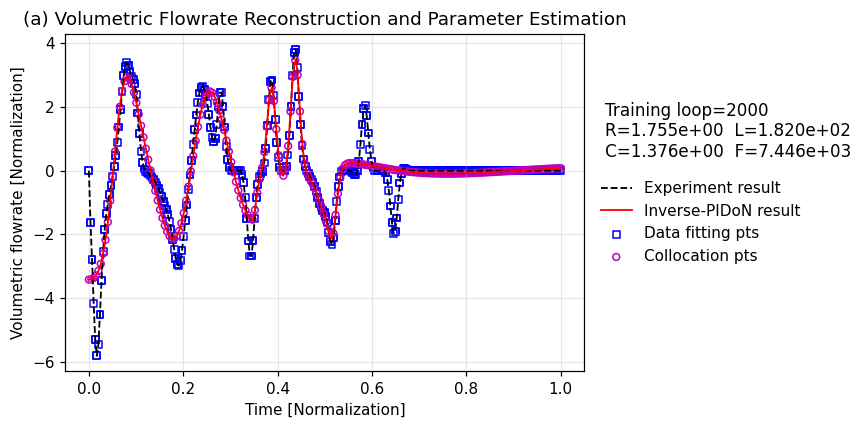

[INFORM] step=2000 | R_est_final=1.755e+00 L_est_final=1.820e+02 | C_est_final=1.376e+00 F_est_final=7.446e+03


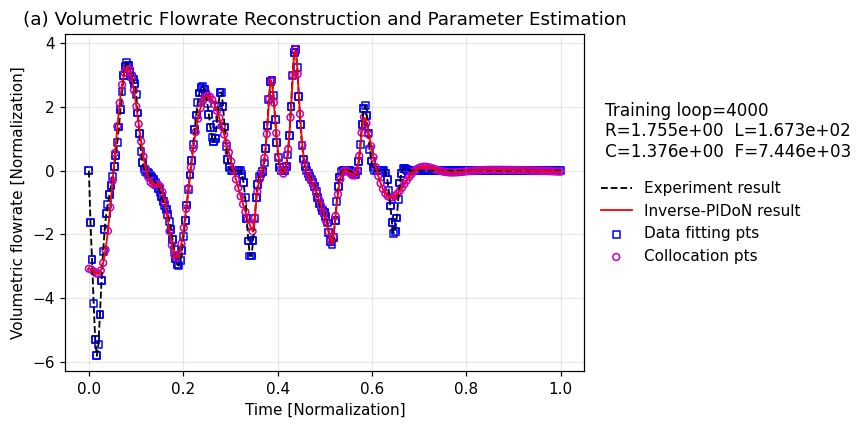

[INFORM] step=4000 | R_est_final=1.755e+00 L_est_final=1.673e+02 | C_est_final=1.376e+00 F_est_final=7.446e+03
  6000 | lr_model 1.00e-07 | lr_R 1.00e-07 | lr_L 1.00e-07 | lr_C 1.00e-07 | lr_F 1.00e-07 | data 1.06e-01 | phys 1.23e+12 | ic 3.14e+00 | R 1.758074e+00 L 1.657705e+02 C 1.375467e+00 F 7.446262e+03


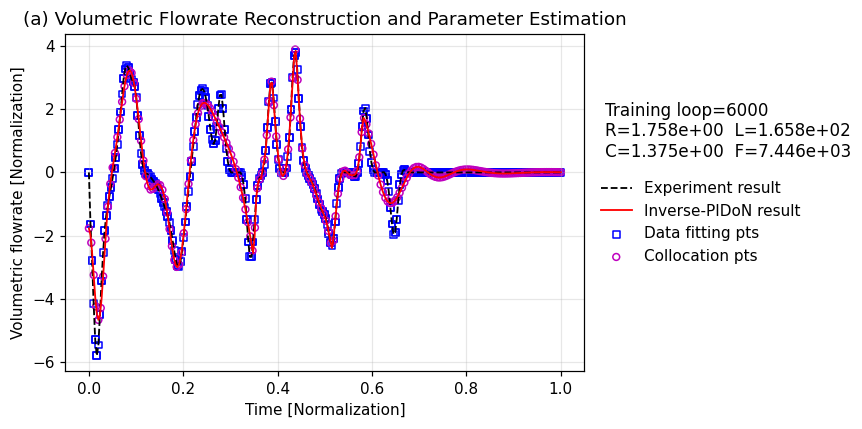

[INFORM] step=6000 | R_est_final=1.758e+00 L_est_final=1.658e+02 | C_est_final=1.375e+00 F_est_final=7.446e+03


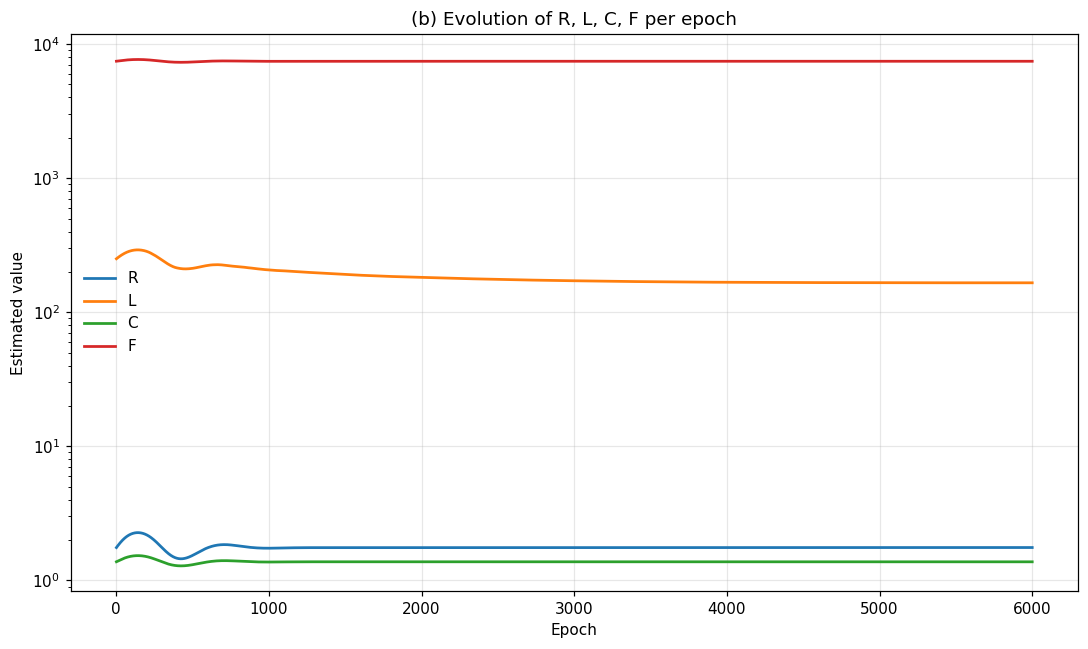

In [36]:
# ═════════════ 0. Library · environment ─══════════════════════════
import math, pandas as pd
from collections import OrderedDict
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import os, sys, re

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(torch.float32)
plt.rcParams["figure.dpi"] = 110

# ═════════════ 1. External forcing term f_ext(t,F) ─═════════════════════════

"""
               [unit conversion]

# L*q_ddot + R*q_dot + (1/C)*q = F*dU_dt [Pa/s]

# L*q_ddot :  [Pa·s^2/m^3] * [m^3/s^3] = [Pa/s]
# R*q_dot  :  [Pa·s/m^3]   * [m^3/s^2] = [Pa/s]
# (1/C)*q  :  [Pa/m^3]     * [m^3/s]   = [Pa/s]
# F*dU_dt  :  [Pa/V]       * [V/s]     = [Pa/s]
"""

# R      : [Pa·s/m^3]      >      [Pa·us/um^3]
# L      : [Pa·s^2/m^3]    >      [Pa·us^2/um^3]
# C      : [m^3/Pa]        >      [um^3/Pa]
# F      : [Pa/V]          >      [Pa/V]

# q      : [m^3/s]         >      [um^3/us]
# q_dot  : [m^3/s^2]       >      [um^3/us^2]
# q_ddot : [m^3/s^3]       >      [um^3/us^3]

# dU_dt  : [V/s]           >      [V/us]

# Ω_time ⊂ [0, 3e-4] > Ω_time ⊂ [0, 1]
Norm_T = 3e-4
t1_phys, t2_phys, t3_phys, V_max = 6e-6, 26e-6, 32e-6, 24
t1 = t1_phys / Norm_T          # [-]
t2 = t2_phys / Norm_T          # [-]
t3 = t3_phys / Norm_T          # [-]

#   Time-axis remapping (value-preserving):
#   T = t / Norm_T,  t ∈ [0, Norm_T]  ⇔  T ∈ [0, 1]
#   f_val(T) := f_val_phys(t) with t = Norm_T·T  (i.e., f_val(T) = f_val_phys(Norm_T·T); numerical values are preserved under the reparameterization)

def f_ext(t, F_gain):  # f_ext [Pa/s]
    f_val = (
        V_max/t1 * (1 - (t > (t1)).float())
        - V_max/(t3 - t2) * ((t > (t2)).float() - (t > (t3)).float())
    )
    return F_gain * (f_val * Norm_T)   # F_gain = F [Pa/V], f_val = dU_dt [V/s] ; f_ext [Pa/s] = F_gain*f_val/Norm_T [Pa/V]*[V/s]/[us] ; recover the original f_ext value '(f_val*Norm_T)'


# ═════════════ 2. Experimental CSV → training·validation set ─══════════════════
"""
n_full : number of points in the full waveform (uniform grid over [0, t_end])
t_full : full time grid of size (n_full, 1)
y_full : full measured flowrate waveform sampled at t_full (shape: (n_full, 1))

n_data : number of supervised data points subsampled from the full waveform (within data_range)
x_data : selected time locations for data loss (t_full indexed by idx), shape: (n_data, 1)
y_data : selected measured values corresponding to x_data, shape: (n_data, 1)
"""
def load_experiment_csv(csv_path, t_end=1.0, n_full=300,
                        data_range=(0.0, 1.0), n_data=500):
    df     = pd.read_csv(csv_path)
    vals   = df.iloc[0, :n_full].astype(np.float32).to_numpy()
    y_full = torch.from_numpy(vals).view(-1, 1).to(DEVICE)
    t_full = torch.linspace(0.0, t_end, n_full, device=DEVICE).view(-1, 1)

    s, e = (int(data_range[0]/t_end*(n_full-1)),
            int(data_range[1]/t_end*(n_full-1)))
    idx  = torch.linspace(s, e, n_data, dtype=torch.long, device=DEVICE)
    return t_full, y_full, t_full[idx], y_full[idx]

csv_path = r"D:\Code review\Parameter identification\EG 100\3. EG100_24V.csv"
t_full, y_full, x_data, y_data = load_experiment_csv(csv_path)


# ═════════════ 3. PIDoN + g-Net ─═════════════════════════════
class PIDoN(nn.Module):
    def __init__(self, latent: int = 32):
        super().__init__()

        self.branch = nn.Sequential(OrderedDict([
            ("b1", nn.Linear(4,   256)), ("a1", nn.GELU()),
            ("b2", nn.Linear(256, 256)), ("a2", nn.GELU()),
            ("b3", nn.Linear(256, 256)), ("a3", nn.GELU()),
            ("b4", nn.Linear(256, 256)), ("a4", nn.GELU()),
            ("b5", nn.Linear(256, 256)), ("a5", nn.GELU()),
            ("b6", nn.Linear(256, 256)), ("a6", nn.GELU()),
            ("bout", nn.Linear(256, latent))
        ]))

        self.trunk = nn.Sequential(OrderedDict([
            ("t1", nn.Linear(1,   256)), ("a1", nn.GELU()),
            ("t2", nn.Linear(256, 256)), ("a2", nn.GELU()),
            ("t3", nn.Linear(256, 256)), ("a3", nn.GELU()),
            ("t4", nn.Linear(256, 256)), ("a4", nn.GELU()),
            ("t5", nn.Linear(256, 256)), ("a5", nn.GELU()),
            ("t6", nn.Linear(256, 256)), ("a6", nn.GELU()),
            ("tout", nn.Linear(256, latent))
        ]))

        self.g_net = nn.Sequential(OrderedDict([
            ("g1", nn.Linear(1,   256)), ("a1", nn.GELU()),
            ("g2", nn.Linear(256, 256)), ("a2", nn.GELU()),
            ("g3", nn.Linear(256, 256)), ("a3", nn.GELU()),
            ("g4", nn.Linear(256, 256)), ("a4", nn.GELU()),
            ("g5", nn.Linear(256, 256)), ("a5", nn.GELU()),
            ("g6", nn.Linear(256, 256)), ("a6", nn.GELU()),
            ("gout", nn.Linear(256, latent))
        ]))

        self.bias = nn.Parameter(torch.zeros(1, 1, dtype=torch.get_default_dtype()))

    def forward(self, t: torch.Tensor, params: torch.Tensor) -> torch.Tensor:
        B = self.branch(params)            # [B, latent]
        T = self.trunk(t)                  # [B, latent]
        G = torch.sigmoid(self.g_net(t))   # [B, latent]
        return torch.sum(B * T * G, dim=1, keepdim=True) + self.bias


model = PIDoN(latent=32).to(DEVICE)

# ═════════════ 4. Estimated parameters (bounded interval + oscillation damping) ─══════════════
R_MIN, R_MAX = 0.5, 3.0  # (0.5, 3.0)
L_MIN, L_MAX = 150, 350  # (150, 350)
C_MIN, C_MAX = 1.0, 1.75  # (1.0, 1.75)
F_MIN, F_MAX = 6900, 8000  # (6900, 8000)

# Trainable raw variables
L_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
R_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
C_raw = nn.Parameter(torch.zeros(1, device=DEVICE))
F_raw = nn.Parameter(torch.zeros(1, device=DEVICE))


def bound_osc(raw, lo, hi, step: int,
              cur_lr: float, lr_init: float,
              amp0: float, cycles_total: float,
              phase: float = 0.0, amp_power: float = 2.0):
    """
    raw_osc = raw + amp(step) * sin(omega*step + phase)
    amp(step) = amp0 * (cur_lr/lr_init)^amp_power
    theta = sigmoid(raw_osc)  ->  param = lo + (hi-lo)*theta  in [lo, hi]
    """
    amp = amp0 * (max(cur_lr / lr_init, 0.0) ** amp_power)
    omega = 2.0 * math.pi * cycles_total / float(EPOCHS)

    sin_term = torch.sin(torch.tensor(omega * step + phase, device=DEVICE, dtype=raw.dtype))
    raw_osc = raw + amp * sin_term

    return lo + (hi - lo) * torch.sigmoid(raw_osc)

# ═════════════ 5. Loss weights & training setup ─═══════════════════
DATA_WEIGHT = 1e5
PHYS_WEIGHT = 1e-9 # 1e-9
IC_WEIGHT   = 1e2
LR_INIT = 1e-3

t_phys = torch.linspace(0, 1, 200, device=DEVICE).view(-1,1).requires_grad_(True)
t_ic   = torch.tensor([[0.0]], device=DEVICE, requires_grad=True)

# Each parameter has its own update weight
PARAM_UPDATE_WEIGHT = {"model": 1.0, "R": 1.0, "L": 1.0, "C": 1.0, "F": 1.0,}

optim = torch.optim.Adam([
    {"params": model.parameters(), "lr": LR_INIT * PARAM_UPDATE_WEIGHT["model"]},
    {"params": [R_raw],            "lr": LR_INIT * PARAM_UPDATE_WEIGHT["R"]},
    {"params": [L_raw],            "lr": LR_INIT * PARAM_UPDATE_WEIGHT["L"]},
    {"params": [C_raw],            "lr": LR_INIT * PARAM_UPDATE_WEIGHT["C"]},
    {"params": [F_raw],            "lr": LR_INIT * PARAM_UPDATE_WEIGHT["F"]},
])

EPOCHS       = 6_000
PRINT_EVERY  = 6_000
PLOT_EVERY   = 2_000

# Keep the ratio between parameter groups during scheduling
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=EPOCHS, eta_min=LR_INIT*1e-4)

# ═════════════ 5-1. Oscillation hyperparameters ───────────────────────
# amp0: initial oscillation amplitude in raw-space (too large -> unstable swings)
# cycles_total: total number of sine cycles over the entire training
# amp_power: decay rate of the oscillation as lr decreases (typ. 2–4)
# Initial setting: dict(amp0=0.80, cycles_total=25.0, phase=0.0, amp_power=2.5)
OSC_R = dict(amp0=0.95, cycles_total=10, phase=math.pi*2,  amp_power=50)
OSC_L = dict(amp0=0.95, cycles_total=10, phase=math.pi*2,  amp_power=50)
OSC_C = dict(amp0=0.95, cycles_total=10, phase=math.pi*2,  amp_power=50)
OSC_F = dict(amp0=0.95, cycles_total=10, phase=math.pi*2,  amp_power=50)

# ═════════════ 6. Parameter·LR history buffers ─═════════════════════
param_hist = {"epoch": [], "R": [], "L": [], "C": [], "F": []}
lr_hist    = {"epoch": [], "lr_model": [], "lr_R": [], "lr_L": [], "lr_C": [], "lr_F": []}

# ═════════════ 7. Training loop ─═════════════════════════════════
for step in range(1, EPOCHS + 1):
    optim.zero_grad()

    # Use each parameter group's current lr
    cur_lr_R = float(optim.param_groups[1]["lr"])
    cur_lr_L = float(optim.param_groups[2]["lr"])
    cur_lr_C = float(optim.param_groups[3]["lr"])
    cur_lr_F = float(optim.param_groups[4]["lr"])

    # Reconstruct bounded + damped-oscillation parameters
    R_est = bound_osc(R_raw, R_MIN, R_MAX, step, cur_lr_R, LR_INIT * PARAM_UPDATE_WEIGHT["R"], **OSC_R)  # (1,)
    L_est = bound_osc(L_raw, L_MIN, L_MAX, step, cur_lr_L, LR_INIT * PARAM_UPDATE_WEIGHT["L"], **OSC_L)  # (1,)
    C_est = bound_osc(C_raw, C_MIN, C_MAX, step, cur_lr_C, LR_INIT * PARAM_UPDATE_WEIGHT["C"], **OSC_C)  # (1,)
    F_est = bound_osc(F_raw, F_MIN, F_MAX, step, cur_lr_F, LR_INIT * PARAM_UPDATE_WEIGHT["F"], **OSC_F)  # (1,)

    # Model input parameter vector (important: do not use .item() -> keep gradients)
    p_vec = torch.stack([R_est, L_est, C_est, F_est], dim=0).view(1, 4)  # (1,4)

    # (a) Data loss
    """
    y_data, y_phs = q_Norm = q_actual(t) * 1/1000 [um^3/us]
    """
    y_pred_data = model(x_data, p_vec.repeat(x_data.size(0), 1))
    loss_data   = F.mse_loss(y_pred_data, y_data)

    # (b) Physics residual
    """
    # L*q_ddot + R*q_dot + (1/C)*q = F*dU_dt [Pa/s]

    Parameter domain (physical units)
    [LHS]
    - R_est ∈ [0.719e0, 1.716e0]   ([Pa*us/um^3])
    - L_est ∈ [1.606e2, 1.695e2]   ([Pa*us^2/um^3])
    - C_est ∈ [1.442e0, 1.616e0]   ([um^3/Pa])
    [RHS]
    - F_est ∈ [6.994e3, 7.834e3]   ([Pa/V])
    - f_ext = dUdt                 ([Pa/s])

    State/derivatives (time in [us], flowrate in [um^3/us])
    - y_phys = q(t)                ([um^3/us]), with scale approximately -5e4 < q(t) < 5e4
    - dy     = dq/dt               ([um^3/us^2])
    - d2y    = d²q/dt²             ([um^3/us^3])

    # 0) Residual form: each term should have units of [Pa/us]; however, f_ext is in [Pa/s], so a unit conversion is required.
    res = L_est*d2y + R_est*dy + (1.0/C_est)*y_phys - f_ext(t_phys, F_est)

    # 1) f_ext [Pa/s] > [Pa/us]
    res = L_est*d2y + R_est*dy + (1.0/C_est)*y_phys - f_ext(t_phys, F_est) * 1e-6
    # RHS: [Pa/s]*1e-6 = [Pa/us]

    # 2) y_data, y_phs = q_actual(t) * 1/1000 [um^3/us]
    s_q = 1000.0  # q scaling used in data: q_Norm = q_actual / s_q
    res = (L_est*d2y + R_est*dy + (1.0/C_est)*y_phys)*s_q - (f_ext(t_phys, F_est) * 1e-6)
    """
    y_phys = model(t_phys, p_vec.repeat(t_phys.size(0), 1))
    dy  = torch.autograd.grad(y_phys, t_phys, torch.ones_like(y_phys),
                              create_graph=True, retain_graph=True)[0]
    d2y = torch.autograd.grad(dy, t_phys, torch.ones_like(dy),
                              create_graph=True, retain_graph=True)[0]

    s_q = 1e3
    res = (L_est*d2y + R_est*dy + (1.0/C_est)*y_phys) - (f_ext(t_phys, F_est) * 1e-6) / s_q
    loss_phys = res.pow(2).mean()

    # (c) Initial-condition loss
    y0  = model(t_ic, p_vec)
    dy0 = torch.autograd.grad(y0, t_ic, torch.ones_like(y0),
                              create_graph=True, retain_graph=True)[0]
    loss_ic = (y0.pow(2) + dy0.pow(2)).mean()

    # (d) Total loss
    total_loss = (DATA_WEIGHT * loss_data +
                  PHYS_WEIGHT * loss_phys +
                  IC_WEIGHT   * loss_ic)
    total_loss.backward()
    optim.step()
    scheduler.step()

    # (e) Record parameter·LR history
    param_hist["epoch"].append(step)
    param_hist["R"].append(float(R_est.detach().cpu()))
    param_hist["L"].append(float(L_est.detach().cpu()))
    param_hist["C"].append(float(C_est.detach().cpu()))
    param_hist["F"].append(float(F_est.detach().cpu()))

    lr_hist["epoch"].append(step)
    lr_hist["lr_model"].append(float(optim.param_groups[0]["lr"]))
    lr_hist["lr_R"].append(float(optim.param_groups[1]["lr"]))
    lr_hist["lr_L"].append(float(optim.param_groups[2]["lr"]))
    lr_hist["lr_C"].append(float(optim.param_groups[3]["lr"]))
    lr_hist["lr_F"].append(float(optim.param_groups[4]["lr"]))

    if step % PRINT_EVERY == 0:
        print(f"{step:>6} | "
              f"lr_model {optim.param_groups[0]['lr']:.2e} | "
              f"lr_R {optim.param_groups[1]['lr']:.2e} | "
              f"lr_L {optim.param_groups[2]['lr']:.2e} | "
              f"lr_C {optim.param_groups[3]['lr']:.2e} | "
              f"lr_F {optim.param_groups[4]['lr']:.2e} | "
              f"data {loss_data.item():.2e} | "
              f"phys {loss_phys.item():.2e} | "
              f"ic {loss_ic.item():.2e} | "
              f"R {R_est.item():.6e} L {L_est.item():.6e} "
              f"C {C_est.item():.6e} F {F_est.item():.6e}")

    if step % PLOT_EVERY == 0:
        with torch.no_grad():
            y_hat_mid = model(t_full, p_vec.repeat(t_full.size(0), 1)).cpu()
            y_phys_plot = model(t_phys.detach(), p_vec.repeat(t_phys.size(0), 1)).cpu()

        plt.figure(figsize=(8, 4))
        plt.plot(t_full.cpu(), y_full.cpu(), 'k--', lw=1.2, label='Experiment result')
        plt.plot(t_full.cpu(), y_hat_mid, 'r', lw=1.2, label='Inverse-PIDoN result')
        plt.scatter(x_data.cpu(), y_data.cpu(), facecolors='none', edgecolors='b', marker='s', s=20, label='Data fitting pts')
        plt.scatter(t_phys.detach().cpu(), y_phys_plot, facecolors='none', edgecolors='m', marker='o', s=20, label='Collocation pts')
        plt.title("(a) Volumetric Flowrate Reconstruction and Parameter Estimation")
        plt.xlabel("Time [Normalization]")
        plt.ylabel("Volumetric flowrate [Normalization]")
        plt.grid(alpha=0.3)
        plt.legend(frameon=False, loc=(1.02, 0.30))
        plt.text(1.04, 0.80,
                 f"Training loop={step}\n"
                 f"R={R_est.item():.3e}  L={L_est.item():.3e}\n"
                 f"C={C_est.item():.3e}  F={F_est.item():.3e}\n",
                 transform=plt.gca().transAxes, va='top', fontsize=11)
        plt.tight_layout()
        plt.show()

        R_est_final = float(R_est.detach().cpu())
        L_est_final = float(L_est.detach().cpu())
        C_est_final = float(C_est.detach().cpu())
        F_est_final = float(F_est.detach().cpu())

        print(
            f"[INFORM] step={step} | "
            f"R_est_final={R_est_final:.3e} L_est_final={L_est_final:.3e} | "
            f"C_est_final={C_est_final:.3e} F_est_final={F_est_final:.3e}"
        )


# ═════════════ 8. Visualization of [R, L, C, F] / epoch ─═══════════════
plt.figure(figsize=(10, 6))
plt.plot(param_hist["epoch"], param_hist["R"], label="R", lw=1.8)
plt.plot(param_hist["epoch"], param_hist["L"], label="L", lw=1.8)
plt.plot(param_hist["epoch"], param_hist["C"], label="C", lw=1.8)
plt.plot(param_hist["epoch"], param_hist["F"], label="F", lw=1.8)
plt.xlabel("Epoch")
plt.ylabel("Estimated value")
plt.yscale("log")
plt.title("(b) Evolution of R, L, C, F per epoch")
plt.grid(alpha=0.3)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

In [29]:
print(f"R_est_final = {R_est_final:.6e}")
print(f"L_est_final = {L_est_final:.6e}")
print(f"C_est_final = {C_est_final:.6e}")
print(f"F_est_final = {F_est_final:.6e}")

R_est_final = 1.753676e+00
L_est_final = 1.597391e+02
C_est_final = 1.371286e+00
F_est_final = 7.447415e+03


In [52]:
import math
import numpy as np
import matplotlib.pyplot as plt

# ═════════════ 1. verify the calculation ══════════════
# ============================================================
# a) Unit conversion (micro-unit system -> SI)
#    NOTE: In this script, C_hat is interpreted as C_nozzle.
# ============================================================
"""
Convert units:
  R_est : [Pa·us/um^3]   -> [Pa·s/m^3]      multiply by 1e12
  L_est : [Pa·us^2/um^3] -> [Pa·s^2/m^3]    multiply by 1e6
  C_est : [um^3/Pa]      -> [m^3/Pa]        multiply by 1e-18   (here: C_est = C_nozzle)
  F_est : [Pa/V]         -> [Pa/V]          unchanged
"""

def micro_to_SI_nozzle(R_est, L_est, C_est, F_est):
    R_SI = float(R_est) * 1e12      # [Pa·s/m^3]
    L_SI = float(L_est) * 1e6       # [Pa·s^2/m^3]
    C_SI = float(C_est) * 1e-18     # [m^3/Pa]   (C_nozzle in SI)
    F_SI = float(F_est)             # [Pa/V]
    return R_SI, L_SI, C_SI, F_SI


# ============================================================
# b) Calculate ink properties assuming C_hat == C_nozzle
#    (infer sigma; c is inferred from F, not from C_channel)
# ============================================================
def infer_ink_properties_from_RLCF_nozzle_only(
    R_est, L_est, C_est, F_est,
    r_m, r_nozz_m, l_tot_m, alpha_m_per_V
):
    # Convert to SI (C_SI is C_nozzle in SI)
    R_SI, L_SI, C_SI, F_SI = micro_to_SI_nozzle(R_est, L_est, C_est, F_est)

    # (i) rho from inertance: L = rho*l/(pi*r^2)
    rho_est = L_SI * math.pi * (r_m**2) / l_tot_m  # [kg/m^3]

    # (ii) c from F (using known alpha): F = 2*rho*c^2*alpha / r
    #      c = sqrt(F*r/(2*rho*alpha))
    c_est = math.sqrt((F_SI * r_m) / (2.0 * rho_est * alpha_m_per_V))  # [m/s]

    # (iii) mu from Stokes boundary-layer resistance model (eliminate delta_v):
    # mu = (R^2 * pi * r^6) / (2 * rho * c * l)
    mu_est = (R_SI**2 * math.pi * (r_m**6)) / (2.0 * rho_est * c_est * l_tot_m)  # [Pa·s]

    # (iv) sigma from nozzle compliance: C_nozzle = pi*r_nozz^4 / (3*sigma)
    #      sigma = pi*r_nozz^4 / (3*C_nozzle)
    sigma_est = math.pi * (r_nozz_m**4) / (3.0 * C_SI)  # [N/m]

    # ---- Consistency checks: recompute R, L, C_nozzle, F ----
    L_verif_SI = rho_est * l_tot_m / (math.pi * (r_m**2))  # [Pa·s^2/m^3]

    T_visc = 2.0 * l_tot_m / c_est  # [s]
    delta_v = math.sqrt(mu_est * T_visc / (math.pi * rho_est))  # [m]
    R_verif_SI = 2.0 * mu_est * l_tot_m / (math.pi * delta_v * (r_m**3))  # [Pa·s/m^3]

    F_verif_SI = 2.0 * rho_est * (c_est**2) * alpha_m_per_V / r_m  # [Pa/V]

    C_verif_SI = math.pi * (r_nozz_m**4) / (3.0 * sigma_est)  # [m^3/Pa] (C_nozzle)

    # Convert predictions back to micro-units
    R_verif_est = R_verif_SI / 1e12         # [Pa·us/um^3]
    L_verif_est = L_verif_SI / 1e6          # [Pa·us^2/um^3]
    C_verif_est = C_verif_SI / 1e-18        # [um^3/Pa]  (C_nozzle)
    F_verif_est = F_verif_SI                # [Pa/V]

    def rel_err(verif, ref):
        ref = float(ref)
        verif = float(verif)
        return np.nan if abs(ref) < 1e-30 else (verif - ref) / ref

    out = {
        "rho_est": rho_est,
        "c_est": c_est,
        "mu_est": mu_est,
        "sigma_est": sigma_est,

        "R_est": float(R_est),
        "L_est": float(L_est),
        "C_est": float(C_est),   # C_hat interpreted as C_nozzle [um^3/Pa]
        "F_est": float(F_est),

        "R_verif_est": float(R_verif_est),
        "L_verif_est": float(L_verif_est),
        "C_verif_est": float(C_verif_est),  # recomputed C_nozzle
        "F_verif_est": float(F_verif_est),

        "relerr_R": rel_err(R_verif_est, R_est),
        "relerr_L": rel_err(L_verif_est, L_est),
        "relerr_C": rel_err(C_verif_est, C_est),
        "relerr_F": rel_err(F_verif_est, F_est),
    }
    return out


# =========================
# c) Relative error: error printing for ink properties
# =========================
def rel_err_pct(est, ref):
    ref = float(ref)
    est = float(est)
    return np.nan if abs(ref) < 1e-30 else 100.0 * (est - ref) / ref

def abs_err(est, ref):
    return float(est) - float(ref)


# =========================
# d) Geometry & Ink property inputs: C_hat must be C_nozzle [um^3/Pa]
# =========================
# R_est_final = ...
# L_est_final = ...
# C_est_final = ...
# F_est_final = ...

alpha = 0.29e-9          # [m/V]
r = 235e-6               # [m] channel radius
r_nozz = 25e-6           # [m] nozzle radius
l1, l2, l3, l4 = 0.012, 0.0084, 0.00542303, 0.00057697
l_tot = l1 + l2 + l3 + l4

sigma_ref = 0.0474       # [N/m]
mu_ref    = 0.0157       # [Pa·s]
rho_ref   = 1114.0       # [kg/m^3]
c_ref     = 1688.2       # [m/s]

# =========================
# e) Replace these with your actual reference/theoretical parameter values
# =========================
R_ref = 1.716e+0
L_ref = 1.695e+2
C_ref = 1.442e+0
F_ref = 7.834e+3

result = infer_ink_properties_from_RLCF_nozzle_only(
    R_est_final, L_est_final, C_est_final, F_est_final,
    r_m=r, r_nozz_m=r_nozz, l_tot_m=l_tot, alpha_m_per_V=alpha
)

print("\n=== Consistency check: verify the calculation (recomputed vs inferred, micro-units) ===")
print(f"R_verif = {result['R_verif_est']:.6e}  vs  R_est = {result['R_est']:.6e}  (rel.err = {100*result['relerr_R']:.3e} %)")
print(f"L_verif = {result['L_verif_est']:.6e}  vs  L_est = {result['L_est']:.6e}  (rel.err = {100*result['relerr_L']:.3e} %)")
print(f"C_verif = {result['C_verif_est']:.6e}  vs  C_est = {result['C_est']:.6e}  (rel.err = {100*result['relerr_C']:.3e} %)")
print(f"F_verif = {result['F_verif_est']:.6e}  vs  F_est = {result['F_est']:.6e}  (rel.err = {100*result['relerr_F']:.3e} %)")

print("\n=== Ink property error (estimated vs experiment) ===")
print(f"rho   : est = {result['rho_est']:.6f} [kg/m^3]    vs  ref = {rho_ref:.6f} [kg/m^3]    |  abs.err = {abs_err(result['rho_est'], rho_ref):.6e}  |  rel.err = {rel_err_pct(result['rho_est'], rho_ref):.3e} %")
print(f"c     : est = {result['c_est']:.6f} [m/s]       vs  ref = {c_ref:.6f} [m/s]       |  abs.err = {abs_err(result['c_est'], c_ref):.6e}  |  rel.err = {rel_err_pct(result['c_est'], c_ref):.3e} %")
print(f"mu    : est = {result['mu_est']:.6e} [Pa·s]     vs  ref = {mu_ref:.6e} [Pa·s]     |  abs.err = {abs_err(result['mu_est'], mu_ref):.6e}   |  rel.err = {rel_err_pct(result['mu_est'], mu_ref):.3e} %")
print(f"sigma : est = {result['sigma_est']:.6e} [N/m]      vs  ref = {sigma_ref:.6e} [N/m]      |  abs.err = {abs_err(result['sigma_est'], sigma_ref):.6e}   |  rel.err = {rel_err_pct(result['sigma_est'], sigma_ref):.3e} %")

print("\n=== Parameter R, L, C, F error (estimated vs theoretical) ===")
print(f"R     : est = {result['R_est']:.6e} [Pa·us/um^3]    vs  ref = {float(R_ref):.6e} [Pa·us/um^3]    |  abs.err = {abs_err(result['R_est'], R_ref):.6e}  |  rel.err = {rel_err_pct(result['R_est'], R_ref):.3e} %")
print(f"L     : est = {result['L_est']:.6e} [Pa·us^2/um^3]  vs  ref = {float(L_ref):.6e} [Pa·us^2/um^3]  |  abs.err = {abs_err(result['L_est'], L_ref):.6e}  |  rel.err = {rel_err_pct(result['L_est'], L_ref):.3e} %")
print(f"C     : est = {result['C_est']:.6e} [um^3/Pa]       vs  ref = {float(C_ref):.6e} [um^3/Pa]       |  abs.err = {abs_err(result['C_est'], C_ref):.6e}  |  rel.err = {rel_err_pct(result['C_est'], C_ref):.3e} %")
print(f"F     : est = {result['F_est']:.6e} [Pa/V]          vs  ref = {float(F_ref):.6e} [Pa/V]          |  abs.err = {abs_err(result['F_est'], F_ref):.6e}  |  rel.err = {rel_err_pct(result['F_est'], F_ref):.3e} %")


=== Consistency check: verify the calculation (recomputed vs inferred, micro-units) ===
R_verif = 1.758074e+00  vs  R_est = 1.758074e+00  (rel.err = 0.000e+00 %)
L_verif = 1.657705e+02  vs  L_est = 1.657705e+02  (rel.err = 0.000e+00 %)
C_verif = 1.375467e+00  vs  C_est = 1.375467e+00  (rel.err = -1.614e-14 %)
F_verif = 7.446262e+03  vs  F_est = 7.446262e+03  (rel.err = 1.221e-14 %)

=== Ink property error (estimated vs experiment) ===
rho   : est = 1089.403831 [kg/m^3]    vs  ref = 1114.000000 [kg/m^3]    |  abs.err = -2.459617e+01  |  rel.err = -2.208e+00 %
c     : est = 1664.158293 [m/s]       vs  ref = 1688.200000 [m/s]       |  abs.err = -2.404171e+01  |  rel.err = -1.424e+00 %
mu    : est = 1.708496e-02 [Pa·s]     vs  ref = 1.570000e-02 [Pa·s]     |  abs.err = 1.384963e-03   |  rel.err = 8.821e+00 %
sigma : est = 2.973982e-01 [N/m]      vs  ref = 4.740000e-02 [N/m]      |  abs.err = 2.499982e-01   |  rel.err = 5.274e+02 %

=== Parameter R, L, C, F error (estimated vs theoretical)

### Result 3. Comparison of Ink Properties: (a) Surface Tension, (b) Viscosity, (c) Density, and (d) Speed of Sound

<div align="center">

| Property/Ink | EG 100 | EG 90 | EG 75 | EG 65 | EG 60 | EG 50 |
|---|---:|---:|---:|---:|---:|---:|
| $\sigma_{\mathrm{ref}}\;[\mathrm{N}/\mathrm{m}]$ | 0.0474 | 0.0497 | 0.0521 | 0.0539 | 0.0551 | 0.0565 |
| $\sigma_{\mathrm{est}}\;[\mathrm{N}/\mathrm{m}]$ | 0.0297 | 0.0321 | 0.0332 | 0.0368 | 0.0365 | 0.0394 |
| $\mu_{\mathrm{ref}}\;[\mathrm{Pa}\cdot\mathrm{s}]$ | 0.0157 | 0.0105 | 0.0064 | 0.0049 | 0.0041 | 0.0030 |
| $\mu_{\mathrm{est}}\;[\mathrm{Pa}\cdot\mathrm{s}]$ | 0.0170 | 0.0116 | 0.0067 | 0.0053 | 0.0040 | 0.0034 |
| $\rho_{\mathrm{ref}}\;[\mathrm{kg}/\mathrm{m}^{3}]$ | 1114.00 | 1101.00 | 1081.00 | 1070.00 | 1072.00 | 1056.00 |
| $\rho_{\mathrm{est}}\;[\mathrm{kg}/\mathrm{m}^{3}]$ | 1089.40 | 1079.40 | 1057.80 | 1050.60 | 1048.90 | 1038.70 |
| $c_{\mathrm{ref}}\;[\mathrm{m}/\mathrm{s}]$ | 1688.00 | 1688.00 | 1709.38 | 1707.98 | 1703.27 | 1638.21 |
| $c_{\mathrm{est}}\;[\mathrm{m}/\mathrm{s}]$ | 1664.40 | 1660.80 | 1692.40 | 1682.60 | 1685.70 | 1615.90 |


</div>


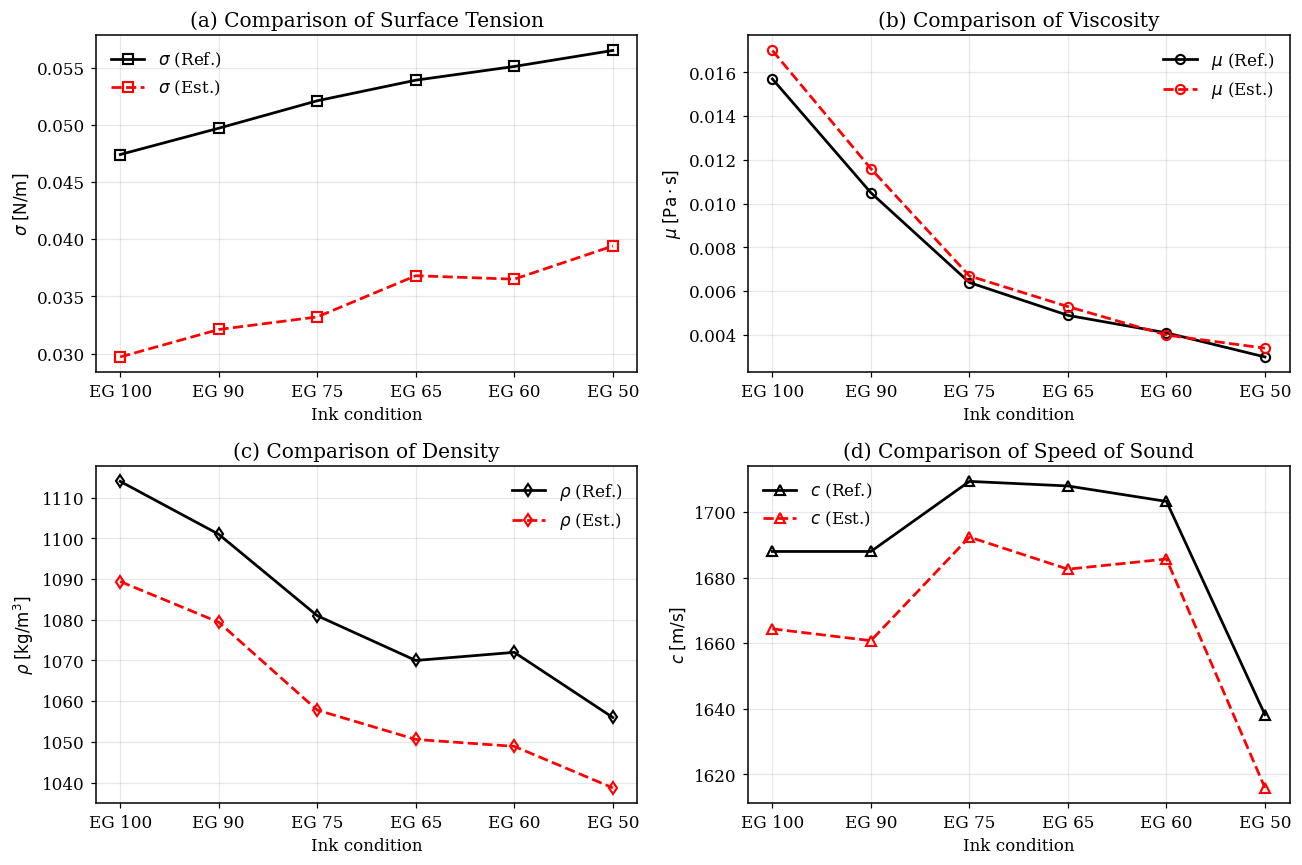

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Data
# ============================================================
inks = ["EG 100", "EG 90", "EG 75", "EG 65", "EG 60", "EG 50"]
x = np.arange(len(inks))

sigma_ref = np.array([0.0474, 0.0497, 0.0521, 0.0539, 0.0551, 0.0565], dtype=float)
sigma_est = np.array([0.0297, 0.0321, 0.0332, 0.0368, 0.0365, 0.0394], dtype=float)

mu_ref = np.array([0.0157, 0.0105, 0.0064, 0.0049, 0.0041, 0.0030], dtype=float)
mu_est = np.array([0.0170, 0.0116, 0.0067, 0.0053, 0.0040, 0.0034], dtype=float)

rho_ref = np.array([1114.00, 1101.00, 1081.00, 1070.00, 1072.00, 1056.00], dtype=float)
rho_est = np.array([1089.40, 1079.40, 1057.80, 1050.60, 1048.90, 1038.70], dtype=float)

c_ref = np.array([1688.00, 1688.00, 1709.38, 1707.98, 1703.27, 1638.21], dtype=float)
c_est = np.array([1664.40, 1660.80, 1692.40, 1682.60, 1685.70, 1615.90], dtype=float)

# ============================================================
# 2. Plot setting
# ============================================================
plt.rcParams.update({"font.family": "serif", "font.size": 11, "axes.linewidth": 1.0})

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# ============================================================
# 3. (a) sigma
# ============================================================
axes[0].plot(x, sigma_ref, color="k", marker="s", linestyle="-", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label=r"$\sigma$ (Ref.)")
axes[0].plot(x, sigma_est, color="red", marker="s", linestyle="--", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label=r"$\sigma$ (Est.)")
axes[0].set_title(r"(a) Comparison of Surface Tension")
axes[0].set_ylabel(r"$\sigma\;[\mathrm{N}/\mathrm{m}]$")
axes[0].set_xticks(x)
axes[0].set_xticklabels(inks, rotation=0)
axes[0].grid(alpha=0.3)
axes[0].legend(loc="best", frameon=False)

# ============================================================
# 4. (b) mu
# ============================================================
axes[1].plot(x, mu_ref, color="k", marker="o", linestyle="-", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label=r"$\mu$ (Ref.)")
axes[1].plot(x, mu_est, color="red", marker="o", linestyle="--", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label=r"$\mu$ (Est.)")
axes[1].set_title(r"(b) Comparison of Viscosity")
axes[1].set_ylabel(r"$\mu\;[\mathrm{Pa}\cdot\mathrm{s}]$")
axes[1].set_xticks(x)
axes[1].set_xticklabels(inks, rotation=0)
axes[1].grid(alpha=0.3)
axes[1].legend(loc="best", frameon=False)

# ============================================================
# 5. (c) rho
# ============================================================
axes[2].plot(x, rho_ref, color="k", marker="d", linestyle="-", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label=r"$\rho$ (Ref.)")
axes[2].plot(x, rho_est, color="red", marker="d", linestyle="--", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label=r"$\rho$ (Est.)")
axes[2].set_title(r"(c) Comparison of Density")
axes[2].set_ylabel(r"$\rho\;[\mathrm{kg}/\mathrm{m}^{3}]$")
axes[2].set_xticks(x)
axes[2].set_xticklabels(inks, rotation=0)
axes[2].grid(alpha=0.3)
axes[2].legend(loc="best", frameon=False)

# ============================================================
# 6. (d) c
# ============================================================
axes[3].plot(x, c_ref, color="k", marker="^", linestyle="-", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label=r"$c$ (Ref.)")
axes[3].plot(x, c_est, color="red", marker="^", linestyle="--", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label=r"$c$ (Est.)")
axes[3].set_title(r"(d) Comparison of Speed of Sound")
axes[3].set_ylabel(r"$c\;[\mathrm{m}/\mathrm{s}]$")
axes[3].set_xticks(x)
axes[3].set_xticklabels(inks, rotation=0)
axes[3].grid(alpha=0.3)
axes[3].legend(loc="best", frameon=False)

# ============================================================
# 7. Common x-label adjustment
# ============================================================
for ax in axes:
    ax.set_xlabel("Ink condition")

plt.tight_layout()
plt.show()

### Result 4. Comparison of Model Parameters: (a) Resistance, (b) Inductance, (c) Capacitance, and (d) Piezo-Stiffness Coefficient

<div align="center">

| Parameter/Ink | EG 100 | EG 90 | EG 75 | EG 65 | EG 60 | EG 50 |
|---|---:|---:|---:|---:|---:|---:|
| $R_{\mathrm{ref}}\;[\mathrm{Pa}\cdot\mu\mathrm{s}/\mu\mathrm{m}^{3}]$ | $1.716 \times 10^{0}$ | $1.395 \times 10^{0}$ | $1.051 \times 10^{0}$ | $8.540 \times 10^{-1}$ | $8.530 \times 10^{-1}$ | $7.190 \times 10^{-1}$ |
| $R_{\mathrm{est}}\;[\mathrm{Pa}\cdot\mu\mathrm{s}/\mu\mathrm{m}^{3}]$ | $1.758 \times 10^{0}$ | $1.482 \times 10^{0}$ | $1.126 \times 10^{0}$ | $9.420 \times 10^{-1}$ | $8.970 \times 10^{-1}$ | $7.980 \times 10^{-1}$ |
| $L_{\mathrm{ref}}\;[\mathrm{Pa}\cdot\mu\mathrm{s}^{2}/\mu\mathrm{m}^{3}]$ | $1.695 \times 10^{2}$ | $1.675 \times 10^{2}$ | $1.644 \times 10^{2}$ | $1.628 \times 10^{2}$ | $1.631 \times 10^{2}$ | $1.606 \times 10^{2}$ |
| $L_{\mathrm{est}}\;[\mathrm{Pa}\cdot\mu\mathrm{s}^{2}/\mu\mathrm{m}^{3}]$ | $1.657 \times 10^{2}$ | $1.688 \times 10^{2}$ | $1.634 \times 10^{2}$ | $1.654 \times 10^{2}$ | $1.621 \times 10^{2}$ | $1.597 \times 10^{2}$ |
| $C_{\mathrm{ref}}\;[\mu\mathrm{m}^{3}/\mathrm{Pa}]$ | $1.442 \times 10^{0}$ | $1.460 \times 10^{0}$ | $1.450 \times 10^{0}$ | $1.467 \times 10^{0}$ | $1.472 \times 10^{0}$ | $1.616 \times 10^{0}$ |
| $C_{\mathrm{est}}\;[\mu\mathrm{m}^{3}/\mathrm{Pa}]$ | $1.375 \times 10^{0}$ | $1.481 \times 10^{0}$ | $1.426 \times 10^{0}$ | $1.493 \times 10^{0}$ | $1.452 \times 10^{0}$ | $1.572 \times 10^{0}$ |
| $F_{\mathrm{ref}}\;[\mathrm{Pa}/\mathrm{V}]$ | $7.834 \times 10^{3}$ | $7.742 \times 10^{3}$ | $7.795 \times 10^{3}$ | $7.703 \times 10^{3}$ | $7.675 \times 10^{3}$ | $6.994 \times 10^{3}$ |
| $F_{\mathrm{est}}\;[\mathrm{Pa}/\mathrm{V}]$ | $7.446 \times 10^{3}$ | $7.664 \times 10^{3}$ | $7.862 \times 10^{3}$ | $7.562 \times 10^{3}$ | $7.731 \times 10^{3}$ | $6.842 \times 10^{3}$ |

</div>

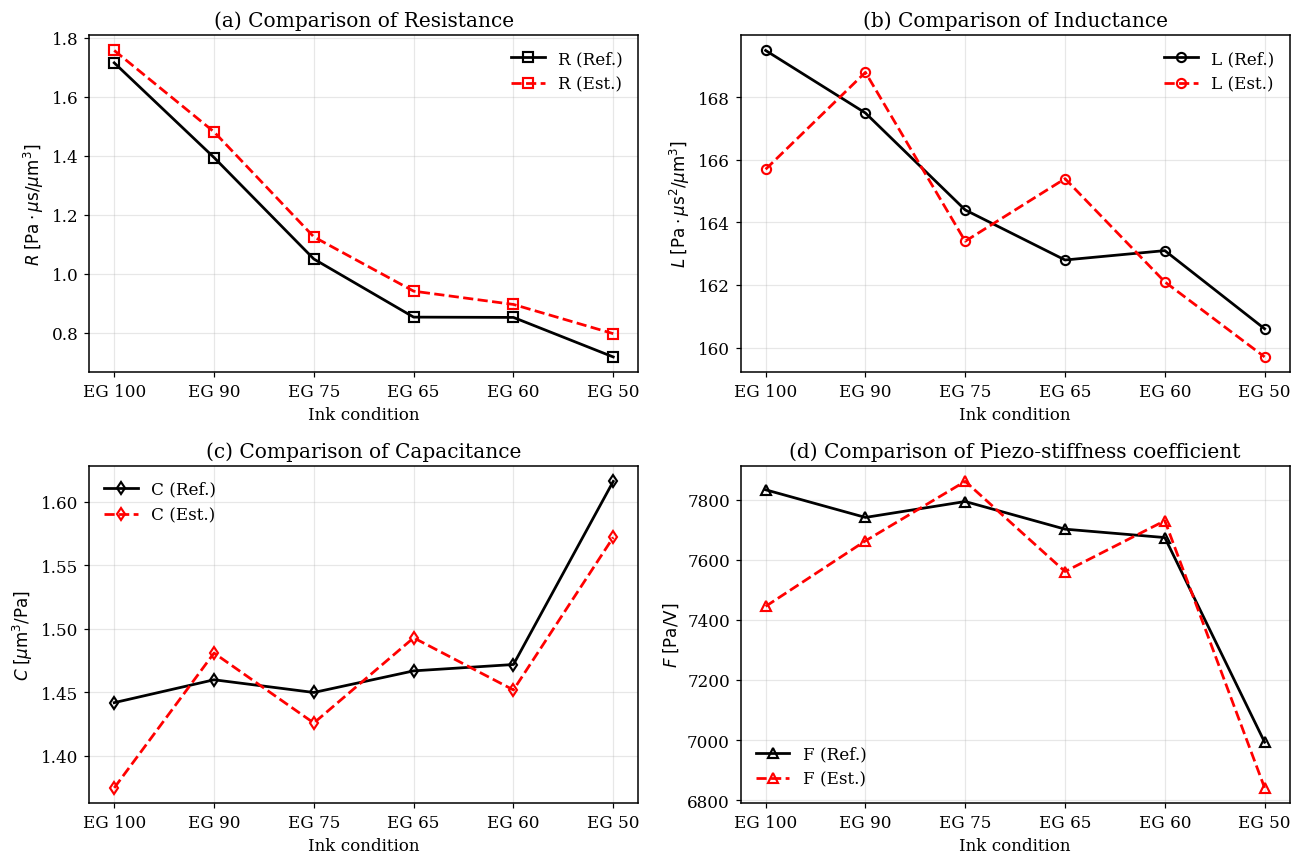

In [58]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. Data
# ============================================================
inks = ["EG 100", "EG 90", "EG 75", "EG 65", "EG 60", "EG 50"]
x = np.arange(len(inks))

R_ref = np.array([1.716e+0, 1.395e+0, 1.051e+0, 8.540e-1, 8.530e-1, 7.190e-1], dtype=float)
R_est = np.array([1.758e+0, 1.482e+0, 1.126e+0, 9.420e-1, 8.970e-1, 7.980e-1], dtype=float)

L_ref = np.array([1.695e+2, 1.675e+2, 1.644e+2, 1.628e+2, 1.631e+2, 1.606e+2], dtype=float)
L_est = np.array([1.657e+2, 1.688e+2, 1.634e+2, 1.654e+2, 1.621e+2, 1.597e+2], dtype=float)

C_ref = np.array([1.442e+0, 1.460e+0, 1.450e+0, 1.467e+0, 1.472e+0, 1.616e+0], dtype=float)
C_est = np.array([1.375e+0, 1.481e+0, 1.426e+0, 1.493e+0, 1.452e+0, 1.572e+0], dtype=float)

F_ref = np.array([7.834e+3, 7.742e+3, 7.795e+3, 7.703e+3, 7.675e+3, 6.994e+3], dtype=float)
F_est = np.array([7.446e+3, 7.664e+3, 7.862e+3, 7.562e+3, 7.731e+3, 6.842e+3], dtype=float)

# ============================================================
# 2. Plot setting
# ============================================================
plt.rcParams.update({"font.family": "serif", "font.size": 11, "axes.linewidth": 1.0})

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# ============================================================
# 3. (a) R
# ============================================================
axes[0].plot(x, R_ref, color="k", marker="s", linestyle="-", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label="R (Ref.)")
axes[0].plot(x, R_est, color="red", marker="s", linestyle="--", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label="R (Est.)")
axes[0].set_title("(a) Comparison of Resistance")
axes[0].set_ylabel(r"$R\;[\mathrm{Pa}\cdot\mu\mathrm{s}/\mu\mathrm{m}^{3}]$")
axes[0].set_xticks(x)
axes[0].set_xticklabels(inks, rotation=0)
axes[0].grid(alpha=0.3)
axes[0].legend(loc="best", frameon=False)

# ============================================================
# 4. (b) L
# ============================================================
axes[1].plot(x, L_ref, color="k", marker="o", linestyle="-", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label="L (Ref.)")
axes[1].plot(x, L_est, color="red", marker="o", linestyle="--", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label="L (Est.)")
axes[1].set_title("(b) Comparison of Inductance")
axes[1].set_ylabel(r"$L\;[\mathrm{Pa}\cdot\mu\mathrm{s}^{2}/\mu\mathrm{m}^{3}]$")
axes[1].set_xticks(x)
axes[1].set_xticklabels(inks, rotation=0)
axes[1].grid(alpha=0.3)
axes[1].legend(loc="best", frameon=False)

# ============================================================
# 5. (c) C
# ============================================================
axes[2].plot(x, C_ref, color="k", marker="d", linestyle="-", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label="C (Ref.)")
axes[2].plot(x, C_est, color="red", marker="d", linestyle="--", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label="C (Est.)")
axes[2].set_title("(c) Comparison of Capacitance")
axes[2].set_ylabel(r"$C\;[\mu\mathrm{m}^{3}/\mathrm{Pa}]$")
axes[2].set_xticks(x)
axes[2].set_xticklabels(inks, rotation=0)
axes[2].grid(alpha=0.3)
axes[2].legend(loc="best", frameon=False)

# ============================================================
# 6. (d) F
# ============================================================
axes[3].plot(x, F_ref, color="k", marker="^", linestyle="-", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label="F (Ref.)")
axes[3].plot(x, F_est, color="red", marker="^", linestyle="--", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label="F (Est.)")
axes[3].set_title("(d) Comparison of Piezo-stiffness coefficient")
axes[3].set_ylabel(r"$F\;[\mathrm{Pa}/\mathrm{V}]$")
axes[3].set_xticks(x)
axes[3].set_xticklabels(inks, rotation=0)
axes[3].grid(alpha=0.3)
axes[3].legend(loc="best", frameon=False)

# ============================================================
# 7. Common x-label adjustment
# ============================================================
for ax in axes:
    ax.set_xlabel("Ink condition")

plt.tight_layout()
plt.show()

### Result 5. Damping parameter analysis: (a) Comparison of Damping Ratio and Quality Factor; (b) Comparison of Amplitude Ratio and Envelope Decay Time

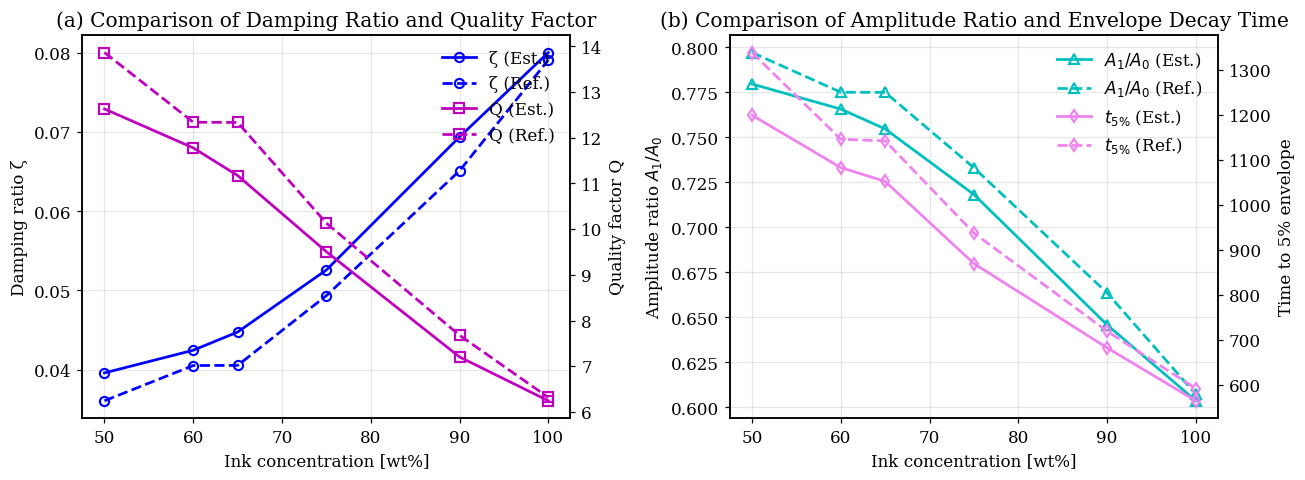

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# -----------------------------
# 1) Input raw data
# -----------------------------
# (A) Estimated values
raw_est = [
    ("EG 100", 100, 1.758e+0, 1.657e+2, 1.375e+0, 7.446e+3),
    ("EG  90",  90, 1.482e+0, 1.688e+2, 1.481e+0, 7.664e+3),
    ("EG  75",  75, 1.126e+0, 1.634e+2, 1.426e+0, 7.862e+3),
    ("EG  65",  65, 9.420e-1, 1.654e+2, 1.493e+0, 7.562e+3),
    ("EG  60",  60, 8.970e-1, 1.621e+2, 1.452e+0, 7.731e+3),
    ("EG  50",  50, 7.980e-1, 1.597e+2, 1.572e+0, 6.842e+3),
]

# (B) Reference values
raw_theo = [
    ("EG 100", 100, 1.716e+0, 1.695e+2, 1.442e+0, 7.834e+3),
    ("EG  90",  90, 1.395e+0, 1.675e+2, 1.460e+0, 7.742e+3),
    ("EG  75",  75, 1.051e+0, 1.644e+2, 1.450e+0, 7.795e+3),
    ("EG  65",  65, 8.540e-1, 1.628e+2, 1.467e+0, 7.703e+3),
    ("EG  60",  60, 8.530e-1, 1.631e+2, 1.472e+0, 7.675e+3),
    ("EG  50",  50, 7.190e-1, 1.606e+2, 1.616e+0, 6.994e+3),
]

# -----------------------------
# 2) Define the metric calculation function
# -----------------------------
def compute_metrics(raw):
    df = pd.DataFrame(raw, columns=["composition", "EG_wt_pct", "R", "L", "C", "F"])
    df = df.sort_values("EG_wt_pct").reset_index(drop=True)
    df["alpha"] = df["R"] / (2.0 * df["L"])
    df["omega0"] = 1.0 / np.sqrt(df["L"] * df["C"])
    df["zeta"] = df["alpha"] / df["omega0"]
    df["Q"] = 1.0 / (2.0 * df["zeta"])
    tmp = np.maximum(df["omega0"]**2 - df["alpha"]**2, 0.0)
    df["omega_d"] = np.sqrt(tmp)
    df["log_dec"] = 2.0 * np.pi * df["zeta"] / np.sqrt(np.maximum(1.0 - df["zeta"]**2, 1e-12))
    df["A1_over_A0"] = np.exp(-df["log_dec"])
    df["t_5pct_envelope"] = np.log(20.0) / df["alpha"]
    df["pole_real"] = -df["alpha"]
    df["pole_imag"] = df["omega_d"]
    return df

df_est = compute_metrics(raw_est)
df_theo = compute_metrics(raw_theo)

# -----------------------------
# 3) Visualization
# -----------------------------
x = df_est["EG_wt_pct"].values

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharex=False)

# -----------------------------
# (a) Comparison of Damping Ratio and Quality Factor
# -----------------------------
ax1 = axes[0]
l1 = ax1.plot(x, df_est["zeta"], color="blue", marker="o", linestyle="-", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label="ζ (Est.)")
l2 = ax1.plot(x, df_theo["zeta"], color="blue", marker="o", linestyle="--", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label="ζ (Ref.)")
ax1.set_xlabel("Ink concentration [wt%]")
ax1.set_ylabel("Damping ratio ζ")
ax1.set_title("(a) Comparison of Damping Ratio and Quality Factor")
ax1.grid(alpha=0.3)

ax1_r = ax1.twinx()
l3 = ax1_r.plot(x, df_est["Q"], color="m", marker="s", linestyle="-", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label="Q (Est.)")
l4 = ax1_r.plot(x, df_theo["Q"], color="m", marker="s", linestyle="--", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label="Q (Ref.)")
ax1_r.set_ylabel("Quality factor Q")

lines1 = l1 + l2 + l3 + l4
labels1 = [line.get_label() for line in lines1]
ax1.legend(lines1, labels1, loc="upper right", frameon=False)

# -----------------------------
# (b) Comparison of Amplitude Ratio and Envelope Decay Time
# -----------------------------
ax2 = axes[1]
l5 = ax2.plot(x, df_est["A1_over_A0"], color="c", marker="^", linestyle="-", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label=r"$A_1/A_0$ (Est.)")
l6 = ax2.plot(x, df_theo["A1_over_A0"], color="c", marker="^", linestyle="--", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label=r"$A_1/A_0$ (Ref.)")
ax2.set_xlabel("Ink concentration [wt%]")
ax2.set_ylabel(r"Amplitude ratio $A_1/A_0$")
ax2.set_title("(b) Comparison of Amplitude Ratio and Envelope Decay Time")
ax2.grid(alpha=0.3)

ax2_r = ax2.twinx()
l7 = ax2_r.plot(x, df_est["t_5pct_envelope"], color="violet", marker="d", linestyle="-", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label=r"$t_{5\%}$ (Est.)")
l8 = ax2_r.plot(x, df_theo["t_5pct_envelope"], color="violet", marker="d", linestyle="--", linewidth=1.8, markersize=6, markerfacecolor="none", markeredgewidth=1.4, label=r"$t_{5\%}$ (Ref.)")
ax2_r.set_ylabel("Time to 5% envelope")

lines2 = l5 + l6 + l7 + l8
labels2 = [line.get_label() for line in lines2]
ax2.legend(lines2, labels2, loc="upper right", frameon=False)

plt.tight_layout()
plt.show()